<a href="https://colab.research.google.com/github/fiss2/fiss2/blob/main/implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tenseal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.0 MB/s eta 0:00:00


In [ ]:
from google.colab import files

# Téléchargez un fichier depuis votre ordinateur
uploaded = files.upload()

# Vérifiez les fichiers téléchargés
for filename in uploaded.keys():
    print(f'Téléchargé : {filename}')

Saving creditcard_2023.csv to creditcard_2023.csv
Téléchargé : creditcard_2023.csv


In [ ]:
import os
print(os.path.exists("creditcard_2023.csv"))  # Affiche True ou False

True


In [ ]:
import torch
import tenseal as ts
import pandas as pd
import random
from time import time
import seaborn as sns

# those are optional and are not necessary for training
import numpy as np
import matplotlib.pyplot as plt

/tmp/ipython-input-2382432470.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = grouped.apply(lambda x: x.sample(grouped.size().min(), random_state=73).reset_index(drop=True))


############# Data summary #############
x_train has shape: torch.Size([398041, 15])
y_train has shape: torch.Size([398041, 1])
x_test has shape: torch.Size([170589, 15])
y_test has shape: torch.Size([170589, 1])
Classe 0 (non-frauduleuse) dans train: 198989
Classe 1 (frauduleuse) dans train: 199052
Classe 0 (non-frauduleuse) dans test: 85326
Classe 1 (frauduleuse) dans test: 85263
#######################################


/tmp/ipython-input-2382432470.py:94: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


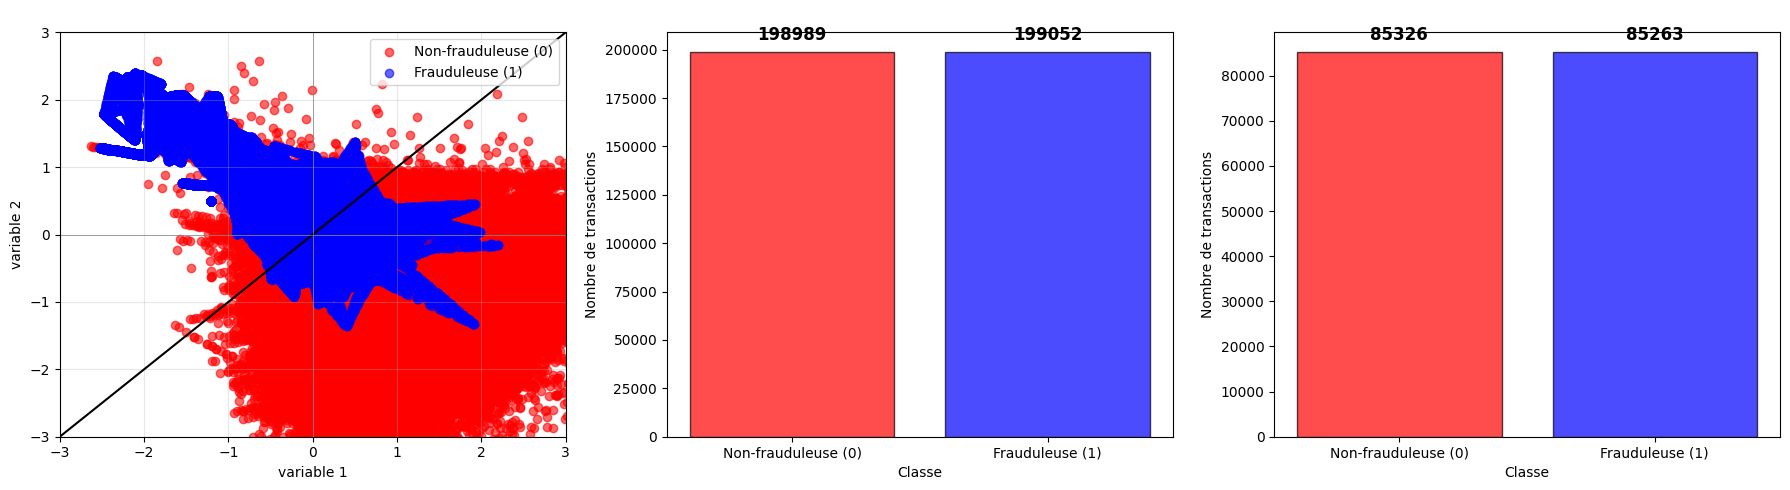

In [ ]:
torch.random.manual_seed(73)
random.seed(73)


def split_train_test(x, y, test_ratio=0.3):
    idxs = [i for i in range(len(x))]
    random.shuffle(idxs)
    # delimiter between test and train data
    delim = int(len(x) * test_ratio)
    test_idxs, train_idxs = idxs[:delim], idxs[delim:]
    return x[train_idxs], y[train_idxs], x[test_idxs], y[test_idxs]


def credit_card_data():
    # Read the CSV file directly
    data = pd.read_csv("creditcard_2023.csv")
    # drop rows with missing values
    data = data.dropna()
    # drop some features
    data = data.drop(columns=["id","V1","V2", "V5","V6", "V13","V15", "V18", "V19", "V21", "V22", "V24", "V26", "V27","V28"])
    # balance data
    grouped = data.groupby('Class')

    data = grouped.apply(lambda x: x.sample(grouped.size().min(), random_state=73).reset_index(drop=True))
    # extract labels
    y = torch.tensor(data["Class"].values).float().unsqueeze(1)
    data = data.drop("Class", axis=1)
    # standardize data
    data = (data - data.mean()) / data.std()
    x = torch.tensor(data.values).float()
    return split_train_test(x, y)

#x_train, y_train, x_test, y_test = random_data()
x_train, y_train, x_test, y_test = credit_card_data()

print("############# Data summary #############")
print(f"x_train has shape: {x_train.shape}")
print(f"y_train has shape: {y_train.shape}")
print(f"x_test has shape: {x_test.shape}")
print(f"y_test has shape: {y_test.shape}")
print(f"Classe 0 (non-frauduleuse) dans train: {(y_train == 0).sum().item()}")
print(f"Classe 1 (frauduleuse) dans train: {(y_train == 1).sum().item()}")
print(f"Classe 0 (non-frauduleuse) dans test: {(y_test == 0).sum().item()}")
print(f"Classe 1 (frauduleuse) dans test: {(y_test == 1).sum().item()}")
print("#######################################")

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Scatter plot des données d'entraînement
axes[0].scatter(x_train[y_train.squeeze() == 0, 0], x_train[y_train.squeeze() == 0, 1],
                color='red', label='Non-frauduleuse (0)', alpha=0.6)
axes[0].scatter(x_train[y_train.squeeze() == 1, 0], x_train[y_train.squeeze() == 1, 1],
                color='blue', label='Frauduleuse (1)', alpha=0.6)
axes[0].plot([-3, 3], [-3, 3], color='black', linestyle='-')
axes[0].set_title(' ')
axes[0].set_xlabel('variable 1')
axes[0].set_ylabel('variable 2')
axes[0].set_xlim(-3, 3)
axes[0].set_ylim(-3, 3)
axes[0].axhline(0, color='grey', lw=0.5)
axes[0].axvline(0, color='grey', lw=0.5)
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Histogramme pour l'ensemble d'entraînement
train_counts = [
    (y_train == 0).sum().item(),
    (y_train == 1).sum().item()
]
axes[1].bar(['Non-frauduleuse (0)', 'Frauduleuse (1)'], train_counts,
            color=['red', 'blue'], alpha=0.7, edgecolor='black')
axes[1].set_title('')
axes[1].set_ylabel('Nombre de transactions')
axes[1].set_xlabel('Classe')
for i, count in enumerate(train_counts):
    axes[1].text(i, count + max(train_counts)*0.02, str(count),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

# 3. Histogramme pour l'ensemble de test
test_counts = [
    (y_test == 0).sum().item(),
    (y_test == 1).sum().item()
]
axes[2].bar(['Non-frauduleuse (0)', 'Frauduleuse (1)'], test_counts,
            color=['red', 'blue'], alpha=0.7, edgecolor='black')
axes[2].set_title('')
axes[2].set_ylabel('Nombre de transactions')
axes[2].set_xlabel('Classe')
for i, count in enumerate(test_counts):
    axes[2].text(i, count + max(test_counts)*0.02, str(count),
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Epoch 1: Loss = 0.762308, Accuracy = 0.9038
Epoch 2: Loss = 0.257439, Accuracy = 0.9125
Epoch 3: Loss = 0.238939, Accuracy = 0.9157
Epoch 4: Loss = 0.224746, Accuracy = 0.9191
Epoch 5: Loss = 0.213494, Accuracy = 0.9300
Epoch 6: Loss = 0.204349, Accuracy = 0.9332
Epoch 7: Loss = 0.196761, Accuracy = 0.9345
Epoch 8: Loss = 0.190352, Accuracy = 0.9352
Epoch 9: Loss = 0.184857, Accuracy = 0.9361
Epoch 10: Loss = 0.180084, Accuracy = 0.9374

Temps d'entraînement total: 0.2664 secondes
Temps moyen par époque: 0.0266 secondes



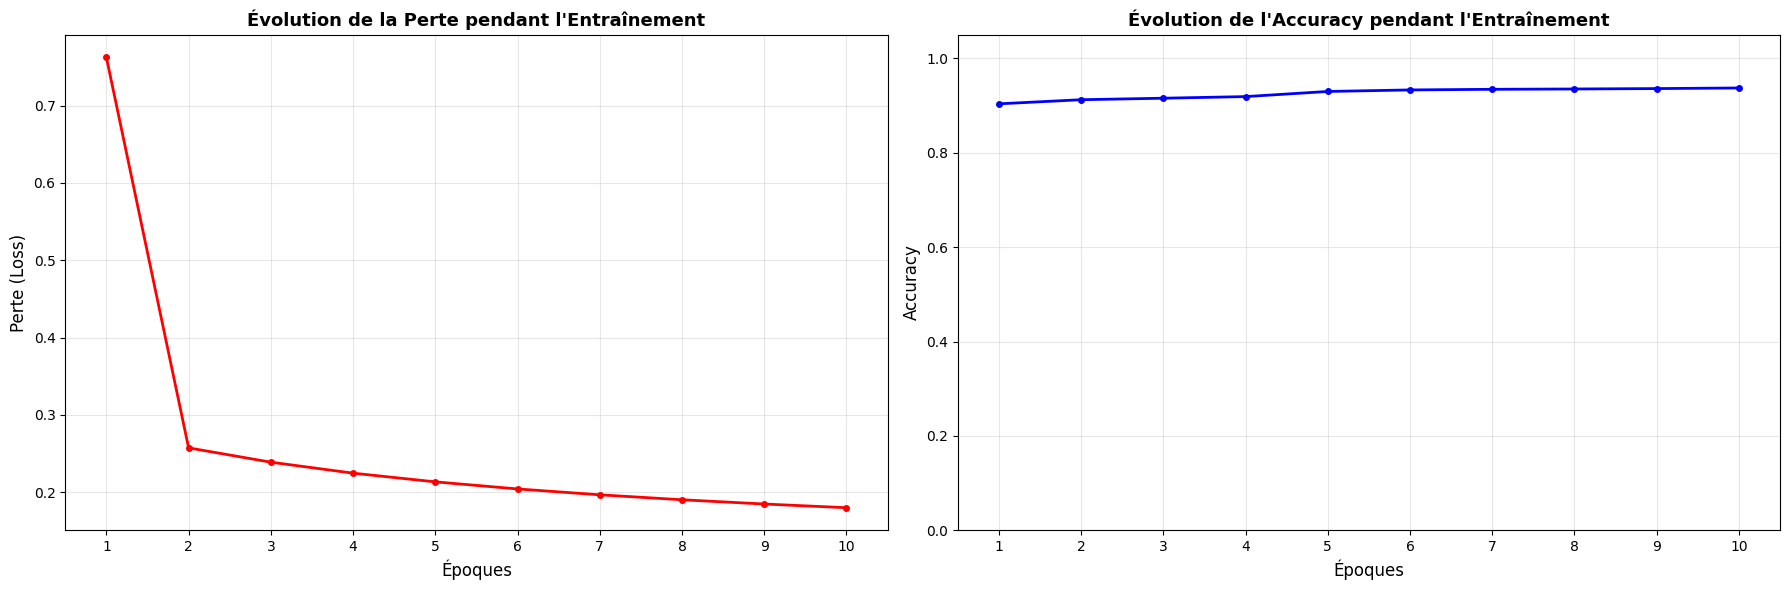

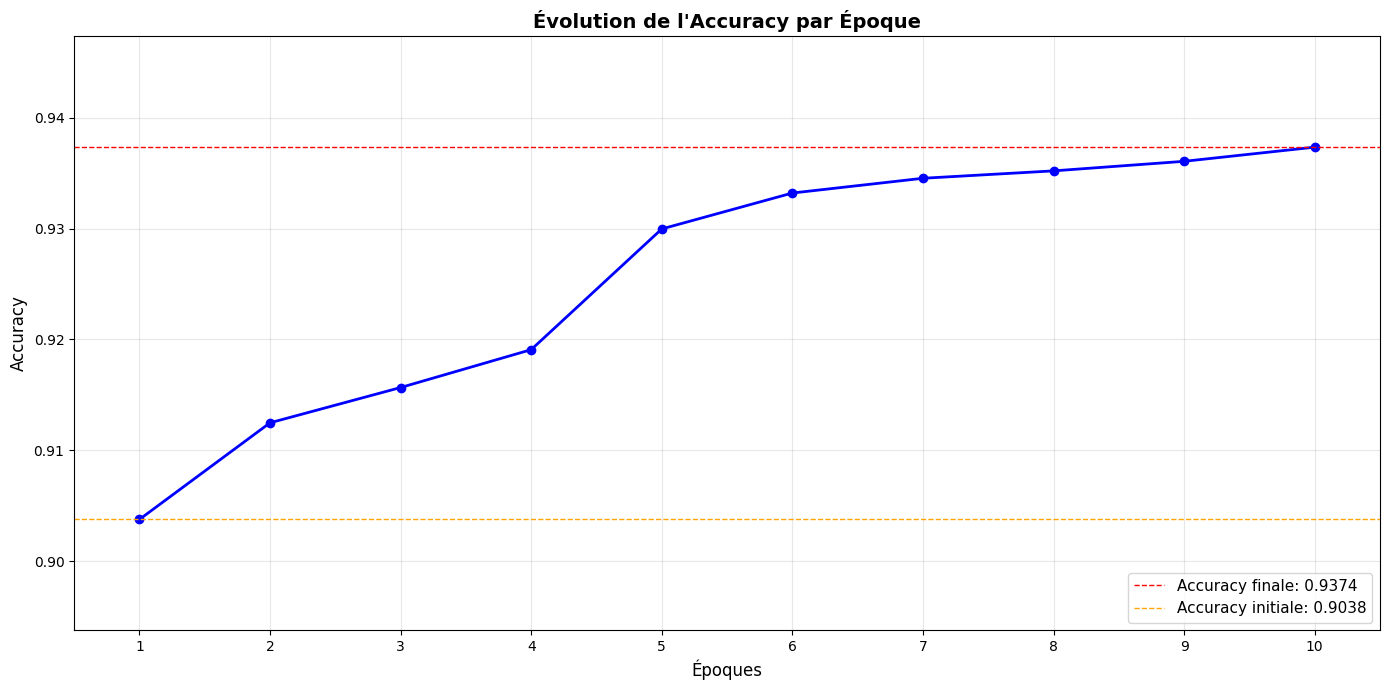

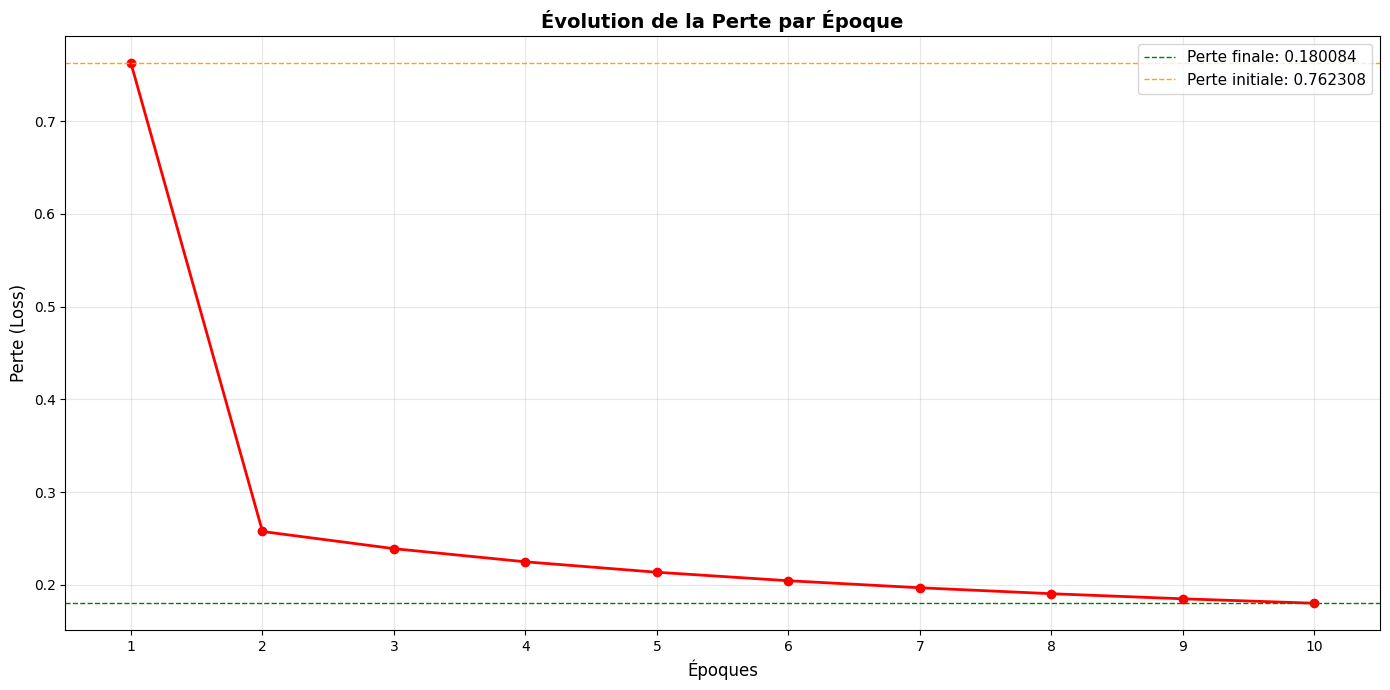


DÉBUT DE L'ÉVALUATION SUR L'ENSEMBLE DE TEST

ÉVALUATION SUR L'ENSEMBLE TEST

──────────────────────────────────────────────────────────────────────
MÉTRIQUES DE PERFORMANCE
──────────────────────────────────────────────────────────────────────
Accuracy:  0.9374  (temps: 3.50 ms)
Recall:    0.8791  (temps: 17.84 ms)
F1-Score:  0.9335  (temps: 14.06 ms)
AUC:       0.9875  (temps: 33.02 ms)

──────────────────────────────────────────────────────────────────────
TEMPS DE CALCUL DÉTAILLÉS
──────────────────────────────────────────────────────────────────────
Prédictions:                  2.83 ms
Accuracy:                     3.50 ms
Recall:                      17.84 ms
F1-Score:                    14.06 ms
ROC & AUC:                   33.02 ms
Matrice de confusion:       458.81 ms
Rapport de classification:    47.71 ms
----------------------------------------------------------------------
TEMPS TOTAL D'ÉVALUATION:   577.76 ms (0.5778 s)
───────────────────────────────────────────────────

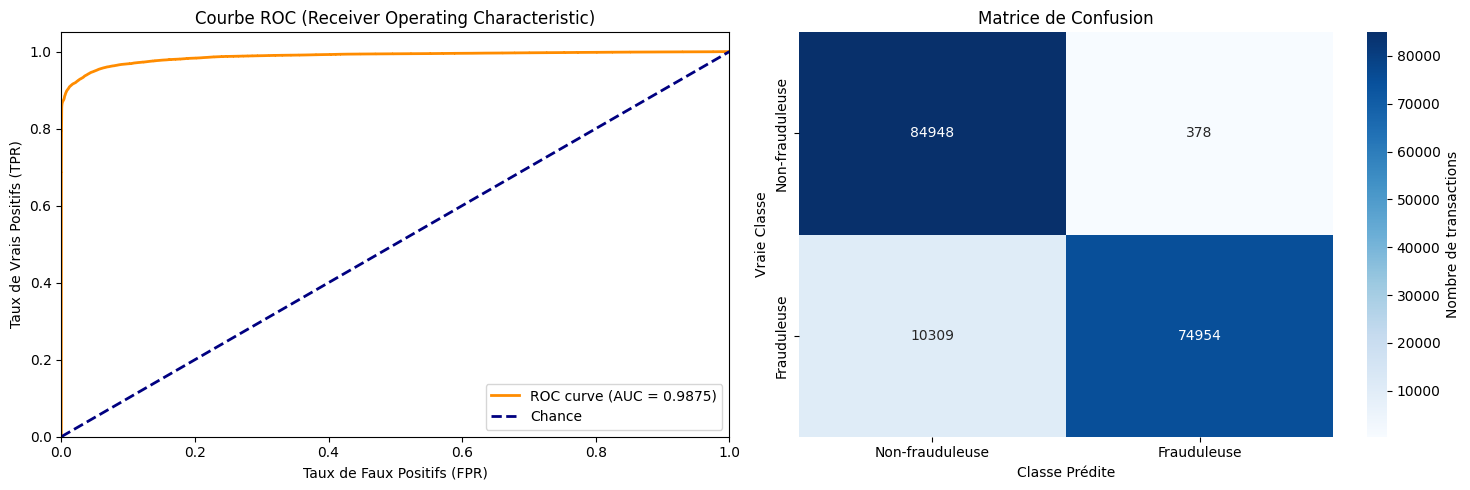

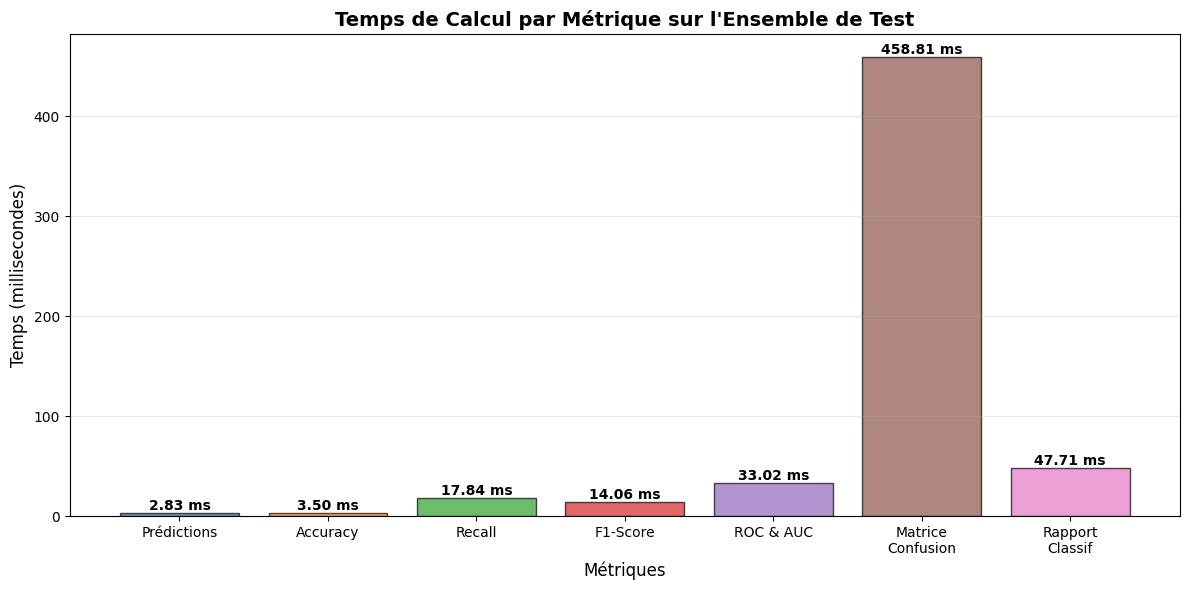

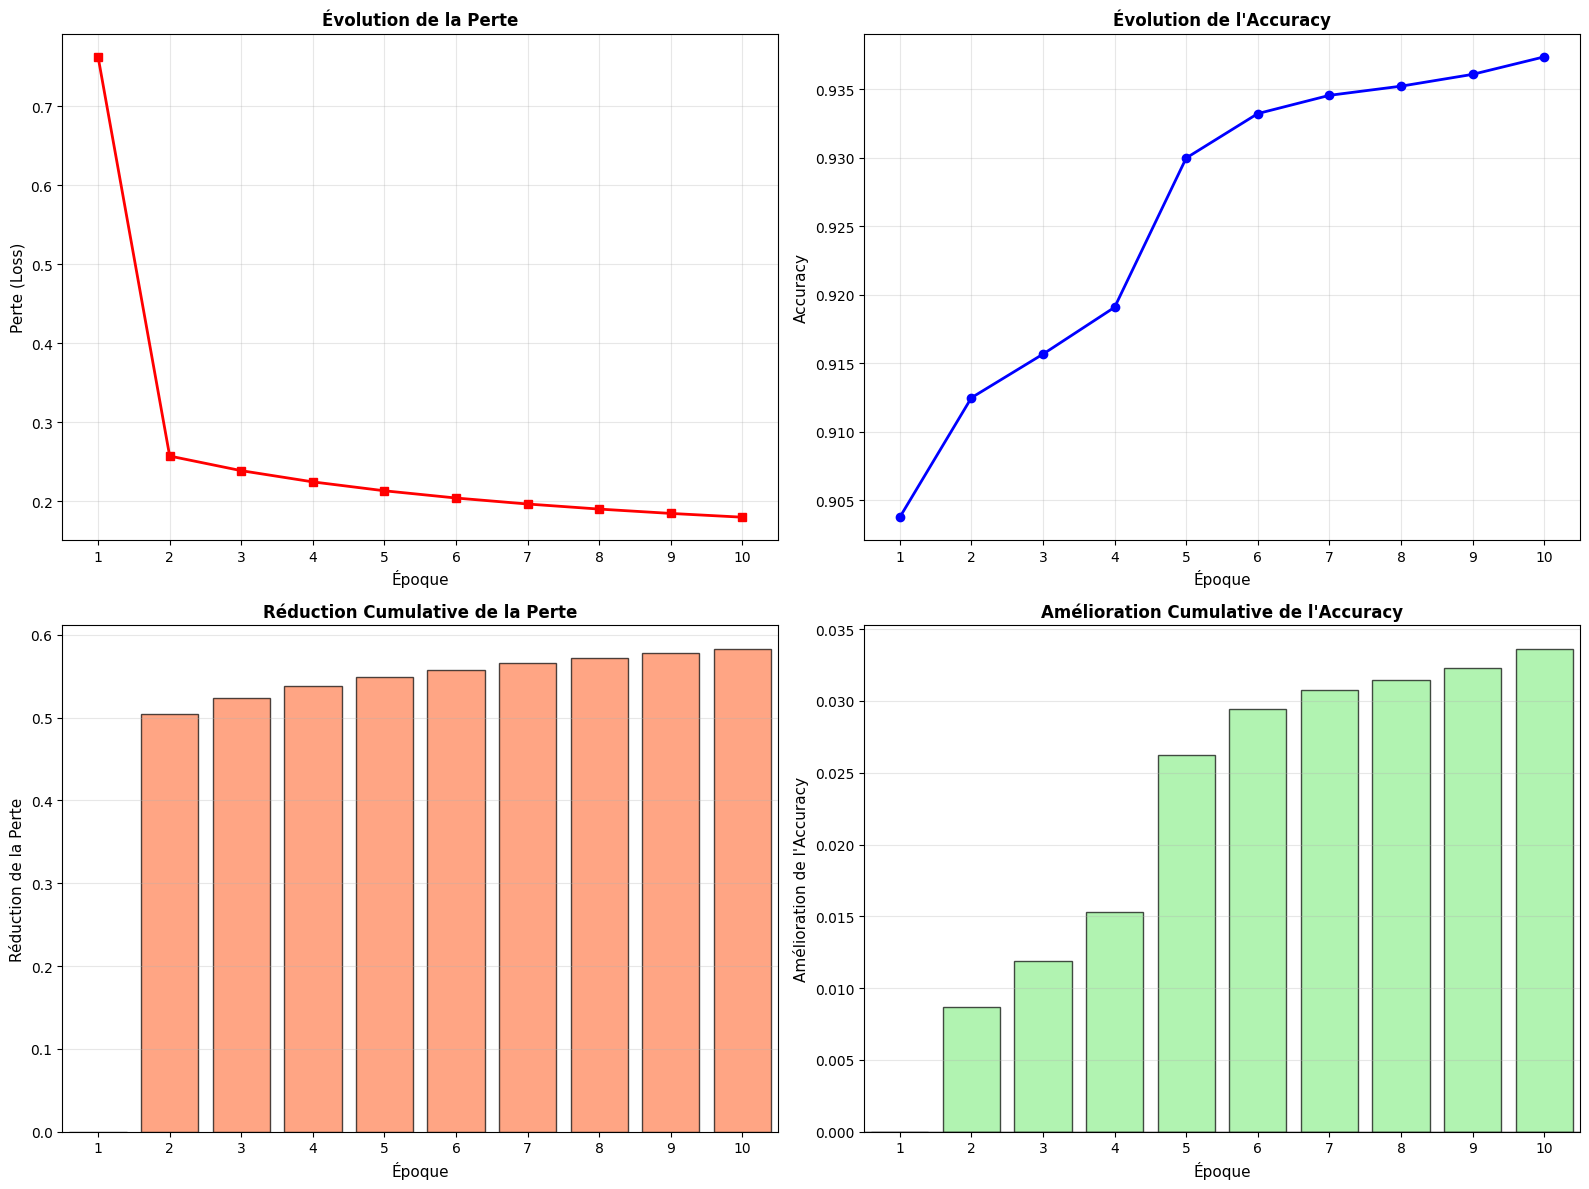


RÉSUMÉ DES MÉTRIQUES ET PERFORMANCES
Accuracy:  93.74% - Proportion de prédictions correctes
Recall:    87.91% - Proportion de fraudes détectées
F1-Score:  93.35% - Moyenne harmonique de précision et rappel
AUC:       98.75% - Aire sous la courbe ROC

Temps total d'évaluation: 577.76 ms
Nombre d'observations évaluées: 170,589
Temps moyen par observation: 0.0034 ms


Tableau récapitulatif des métriques avec temps de calcul:
Métrique   Valeur  Temps (ms)
Accuracy 0.937352    3.501177
  Recall 0.879092   17.836094
F1-Score 0.933454   14.060974
     AUC 0.987465   33.015490

STATISTIQUES D'ENTRAÎNEMENT
Nombre d'époques: 10
Temps total d'entraînement: 0.27 s (0.00 min)
Temps moyen par époque: 0.03 s

Accuracy initiale (époque 1): 0.9038
Accuracy finale (époque 10): 0.9374
Amélioration de l'accuracy: +0.0336

Perte initiale (époque 1): 0.762308
Perte finale (époque 10): 0.180084
Réduction de la perte: 0.582224



In [ ]:
torch.random.manual_seed(73)
random.seed(73)
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
from time import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class LR(torch.nn.Module):
    def __init__(self, n_features):
        super(LR, self).__init__()
        self.lr = torch.nn.Linear(n_features, 1)

    def forward(self, x):
        out = torch.sigmoid(self.lr(x))
        return out

n_features = x_train.shape[1]
model = LR(n_features)
# use gradient descent with a learning_rate=1
optim = torch.optim.SGD(model.parameters(), lr=1)
# use Binary Cross Entropy Loss
criterion = torch.nn.BCELoss()
# define the number of epochs for both plain and encrypted training
EPOCHS = 10

def train(model, optim, criterion, x_train, y_train, x_test, y_test, epochs=EPOCHS):
    loss_history = []  # Pour stocker l'historique des pertes
    accuracy_history = []  # Pour stocker l'historique de l'accuracy

    start_time = time()  # Temps de début d'entraînement

    for e in range(1, epochs + 1):
        # Phase d'entraînement
        model.train()
        optim.zero_grad()
        out = model(x_train)
        loss = criterion(out, y_train)
        loss.backward()
        optim.step()

        loss_value = loss.item()
        loss_history.append(loss_value)

        # Calculer l'accuracy sur l'ensemble de test
        model.eval()
        with torch.no_grad():
            test_out = model(x_test)
            correct = torch.abs(y_test - test_out) < 0.5
            acc = correct.float().mean().item()
            accuracy_history.append(acc)

        print(f"Epoch {e}: Loss = {loss_value:.6f}, Accuracy = {acc:.4f}")

    training_time = time() - start_time  # Temps total d'entraînement

    print(f"\n{'='*50}")
    print(f"Temps d'entraînement total: {training_time:.4f} secondes")
    print(f"Temps moyen par époque: {training_time/epochs:.4f} secondes")
    print(f"{'='*50}\n")

    return model, loss_history, accuracy_history, training_time

model, loss_history, accuracy_history, training_time = train(model, optim, criterion,
                                                               x_train, y_train, x_test, y_test)

# ============================================================================
# VISUALISATIONS: PERTE ET ACCURACY PAR ÉPOQUE
# ============================================================================

# Créer les axes X pour les époques (de 1 à EPOCHS)
epochs_axis = np.arange(1, EPOCHS + 1)

# Figure combinée: Perte et Accuracy
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1: Courbe de perte
axes[0].plot(epochs_axis, loss_history, marker='o', linestyle='-',
             color='red', linewidth=2, markersize=4)
axes[0].set_xlabel('Époques', fontsize=12)
axes[0].set_ylabel('Perte (Loss)', fontsize=12)
axes[0].set_title('Évolution de la Perte pendant l\'Entraînement', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
# Graduations de 1 à 10
axes[0].set_xticks(epochs_axis)
axes[0].set_xlim([0.5, EPOCHS + 0.5])

# Graphique 2: Courbe d'accuracy
axes[1].plot(epochs_axis, accuracy_history, marker='o', linestyle='-',
             color='blue', linewidth=2, markersize=4)
axes[1].set_xlabel('Époques', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Évolution de l\'Accuracy pendant l\'Entraînement', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
# Graduations de 1 à 10
axes[1].set_xticks(epochs_axis)
axes[1].set_xlim([0.5, EPOCHS + 0.5])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Graphique séparé pour l'accuracy (plus grand)
plt.figure(figsize=(14, 7))
plt.plot(epochs_axis, accuracy_history, marker='o', linestyle='-',
         color='blue', linewidth=2, markersize=6)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Évolution de l\'Accuracy par Époque', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
# Graduations de 1 à 10
plt.xticks(epochs_axis)
plt.xlim([0.5, EPOCHS + 0.5])
plt.ylim([min(accuracy_history) - 0.01, max(accuracy_history) + 0.01])

# Ajouter des annotations pour les valeurs clés
plt.axhline(y=accuracy_history[-1], color='red', linestyle='--', linewidth=1,
            label=f'Accuracy finale: {accuracy_history[-1]:.4f}')
plt.axhline(y=accuracy_history[0], color='orange', linestyle='--', linewidth=1,
            label=f'Accuracy initiale: {accuracy_history[0]:.4f}')
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

# Graphique séparé pour la perte (plus grand)
plt.figure(figsize=(14, 7))
plt.plot(epochs_axis, loss_history, marker='o', linestyle='-',
         color='red', linewidth=2, markersize=6)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Perte (Loss)', fontsize=12)
plt.title('Évolution de la Perte par Époque', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
# Graduations de 1 à 10
plt.xticks(epochs_axis)
plt.xlim([0.5, EPOCHS + 0.5])

# Ajouter des annotations pour les valeurs clés
plt.axhline(y=loss_history[-1], color='green', linestyle='--', linewidth=1,
            label=f'Perte finale: {loss_history[-1]:.6f}')
plt.axhline(y=loss_history[0], color='orange', linestyle='--', linewidth=1,
            label=f'Perte initiale: {loss_history[0]:.6f}')
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

def accuracy(model, x, y):
    out = model(x)
    correct = torch.abs(y - out) < 0.5
    return correct.float().mean()


def evaluate_model(model, x, y, dataset_name="Test"):
    """
    Évalue le modèle avec plusieurs métriques et affiche les résultats avec temps de calcul
    """
    model.eval()

    # Dictionnaire pour stocker les temps de calcul
    timing = {}

    # ============================================================================
    # 1. PRÉDICTIONS
    # ============================================================================
    start_time = time()
    with torch.no_grad():
        # Prédictions (probabilités)
        y_pred_proba = model(x).squeeze().numpy()
        # Prédictions binaires (seuil 0.5)
        y_pred = (y_pred_proba >= 0.5).astype(int)
        y_true = y.squeeze().numpy()
    timing['predictions'] = time() - start_time

    # ============================================================================
    # 2. CALCUL DE L'ACCURACY
    # ============================================================================
    start_time = time()
    acc = accuracy(model, x, y).item()
    timing['accuracy'] = time() - start_time

    # ============================================================================
    # 3. CALCUL DU RECALL
    # ============================================================================
    start_time = time()
    recall = recall_score(y_true, y_pred)
    timing['recall'] = time() - start_time

    # ============================================================================
    # 4. CALCUL DU F1-SCORE
    # ============================================================================
    start_time = time()
    f1 = f1_score(y_true, y_pred)
    timing['f1_score'] = time() - start_time

    # ============================================================================
    # 5. CALCUL DE LA COURBE ROC ET AUC
    # ============================================================================
    start_time = time()
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    timing['roc_auc'] = time() - start_time

    # ============================================================================
    # 6. CALCUL DE LA MATRICE DE CONFUSION
    # ============================================================================
    start_time = time()
    cm = confusion_matrix(y_true, y_pred)
    timing['confusion_matrix'] = time() - start_time

    # ============================================================================
    # 7. RAPPORT DE CLASSIFICATION
    # ============================================================================
    start_time = time()
    class_report = classification_report(y_true, y_pred, target_names=['Non-frauduleuse', 'Frauduleuse'])
    timing['classification_report'] = time() - start_time

    # Temps total d'évaluation
    timing['total'] = sum(timing.values())

    # ============================================================================
    # AFFICHAGE DES RÉSULTATS
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"ÉVALUATION SUR L'ENSEMBLE {dataset_name.upper()}")
    print(f"{'='*70}")

    print(f"\n{'─'*70}")
    print("MÉTRIQUES DE PERFORMANCE")
    print(f"{'─'*70}")
    print(f"Accuracy:  {acc:.4f}  (temps: {timing['accuracy']*1000:.2f} ms)")
    print(f"Recall:    {recall:.4f}  (temps: {timing['recall']*1000:.2f} ms)")
    print(f"F1-Score:  {f1:.4f}  (temps: {timing['f1_score']*1000:.2f} ms)")
    print(f"AUC:       {roc_auc:.4f}  (temps: {timing['roc_auc']*1000:.2f} ms)")

    print(f"\n{'─'*70}")
    print("TEMPS DE CALCUL DÉTAILLÉS")
    print(f"{'─'*70}")
    print(f"Prédictions:              {timing['predictions']*1000:8.2f} ms")
    print(f"Accuracy:                 {timing['accuracy']*1000:8.2f} ms")
    print(f"Recall:                   {timing['recall']*1000:8.2f} ms")
    print(f"F1-Score:                 {timing['f1_score']*1000:8.2f} ms")
    print(f"ROC & AUC:                {timing['roc_auc']*1000:8.2f} ms")
    print(f"Matrice de confusion:     {timing['confusion_matrix']*1000:8.2f} ms")
    print(f"Rapport de classification: {timing['classification_report']*1000:8.2f} ms")
    print(f"{'-'*70}")
    print(f"TEMPS TOTAL D'ÉVALUATION: {timing['total']*1000:8.2f} ms ({timing['total']:.4f} s)")
    print(f"{'─'*70}")

    print(f"\nRapport de classification:")
    print(class_report)

    return {
        'accuracy': acc,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'cm': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'timing': timing,  # Ajout des temps de calcul
        'accuracy_history': accuracy_history,  # Historique de l'accuracy
        'loss_history': loss_history  # Historique de la perte
    }

# Évaluation sur l'ensemble de test
print("\n" + "="*70)
print("DÉBUT DE L'ÉVALUATION SUR L'ENSEMBLE DE TEST")
print("="*70)

results = evaluate_model(model, x_test, y_test, "Test")

# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Courbe ROC
axes[0].plot(results['fpr'], results['tpr'], color='darkorange', lw=2,
             label=f'ROC curve (AUC = {results["auc"]:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].set_title('Courbe ROC (Receiver Operating Characteristic)')
axes[0].legend(loc="lower right")

# 2. Matrice de confusion
sns.heatmap(results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-frauduleuse', 'Frauduleuse'],
            yticklabels=['Non-frauduleuse', 'Frauduleuse'],
            ax=axes[1], cbar_kws={'label': 'Nombre de transactions'})
axes[1].set_title('Matrice de Confusion')
axes[1].set_ylabel('Vraie Classe')
axes[1].set_xlabel('Classe Prédite')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALISATION SUPPLÉMENTAIRE : GRAPHIQUE DES TEMPS DE CALCUL
# ============================================================================

# Créer un graphique en barres des temps de calcul
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Prédictions', 'Accuracy', 'Recall', 'F1-Score',
                 'ROC & AUC', 'Matrice\nConfusion', 'Rapport\nClassif']
timing_values = [
    results['timing']['predictions'] * 1000,
    results['timing']['accuracy'] * 1000,
    results['timing']['recall'] * 1000,
    results['timing']['f1_score'] * 1000,
    results['timing']['roc_auc'] * 1000,
    results['timing']['confusion_matrix'] * 1000,
    results['timing']['classification_report'] * 1000
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.bar(metrics_names, timing_values, color=colors, alpha=0.7, edgecolor='black')

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, timing_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2f} ms',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Temps (millisecondes)', fontsize=12)
ax.set_xlabel('Métriques', fontsize=12)
ax.set_title('Temps de Calcul par Métrique sur l\'Ensemble de Test',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALISATION: ÉVOLUTION DÉTAILLÉE (AVEC GRADUATIONS 1-10)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: Perte par époque
axes[0, 0].plot(epochs_axis, loss_history, marker='s', linestyle='-',
               color='red', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Époque', fontsize=11)
axes[0, 0].set_ylabel('Perte (Loss)', fontsize=11)
axes[0, 0].set_title('Évolution de la Perte', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(epochs_axis)
axes[0, 0].set_xlim([0.5, EPOCHS + 0.5])

# Graphique 2: Accuracy par époque
axes[0, 1].plot(epochs_axis, accuracy_history, marker='o', linestyle='-',
               color='blue', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Époque', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Évolution de l\'Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(epochs_axis)
axes[0, 1].set_xlim([0.5, EPOCHS + 0.5])

# Graphique 3: Amélioration de la perte
loss_improvements = [loss_history[0] - loss_history[i] for i in range(len(loss_history))]
axes[1, 0].bar(epochs_axis, loss_improvements, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Époque', fontsize=11)
axes[1, 0].set_ylabel('Réduction de la Perte', fontsize=11)
axes[1, 0].set_title('Réduction Cumulative de la Perte', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')
axes[1, 0].set_xticks(epochs_axis)
axes[1, 0].set_xlim([0.5, EPOCHS + 0.5])

# Graphique 4: Amélioration de l'accuracy
acc_improvements = [accuracy_history[i] - accuracy_history[0] for i in range(len(accuracy_history))]
axes[1, 1].bar(epochs_axis, acc_improvements, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Époque', fontsize=11)
axes[1, 1].set_ylabel('Amélioration de l\'Accuracy', fontsize=11)
axes[1, 1].set_title('Amélioration Cumulative de l\'Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xticks(epochs_axis)
axes[1, 1].set_xlim([0.5, EPOCHS + 0.5])

plt.tight_layout()
plt.show()

# ============================================================================
# RÉSUMÉ FINAL
# ============================================================================

print(f"\n{'='*70}")
print("RÉSUMÉ DES MÉTRIQUES ET PERFORMANCES")
print(f"{'='*70}")
print(f"Accuracy:  {results['accuracy']:.2%} - Proportion de prédictions correctes")
print(f"Recall:    {results['recall']:.2%} - Proportion de fraudes détectées")
print(f"F1-Score:  {results['f1']:.2%} - Moyenne harmonique de précision et rappel")
print(f"AUC:       {results['auc']:.2%} - Aire sous la courbe ROC")
print(f"\nTemps total d'évaluation: {results['timing']['total']*1000:.2f} ms")
print(f"Nombre d'observations évaluées: {len(x_test):,}")
print(f"Temps moyen par observation: {results['timing']['total']/len(x_test)*1000:.4f} ms")
print(f"{'='*70}\n")

# ============================================================================
# EXPORT DES RÉSULTATS AVEC TEMPS DE CALCUL
# ============================================================================

# Créer un DataFrame récapitulatif
summary_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Recall', 'F1-Score', 'AUC'],
    'Valeur': [results['accuracy'], results['recall'], results['f1'], results['auc']],
    'Temps (ms)': [
        results['timing']['accuracy'] * 1000,
        results['timing']['recall'] * 1000,
        results['timing']['f1_score'] * 1000,
        results['timing']['roc_auc'] * 1000
    ]
})

print("\nTableau récapitulatif des métriques avec temps de calcul:")
print(summary_df.to_string(index=False))

# ============================================================================
# STATISTIQUES SUR L'ENTRAÎNEMENT
# ============================================================================

print(f"\n{'='*70}")
print("STATISTIQUES D'ENTRAÎNEMENT")
print(f"{'='*70}")
print(f"Nombre d'époques: {EPOCHS}")
print(f"Temps total d'entraînement: {training_time:.2f} s ({training_time/60:.2f} min)")
print(f"Temps moyen par époque: {training_time/EPOCHS:.2f} s")
print(f"\nAccuracy initiale (époque 1): {accuracy_history[0]:.4f}")
print(f"Accuracy finale (époque {EPOCHS}): {accuracy_history[-1]:.4f}")
print(f"Amélioration de l'accuracy: {accuracy_history[-1] - accuracy_history[0]:+.4f}")
print(f"\nPerte initiale (époque 1): {loss_history[0]:.6f}")
print(f"Perte finale (époque {EPOCHS}): {loss_history[-1]:.6f}")
print(f"Réduction de la perte: {loss_history[0] - loss_history[-1]:.6f}")
print(f"{'='*70}\n")

Epoch 1: Loss = 0.762308, Accuracy = 0.9038
Epoch 2: Loss = 0.257439, Accuracy = 0.9125
Epoch 3: Loss = 0.238939, Accuracy = 0.9157
Epoch 4: Loss = 0.224746, Accuracy = 0.9191
Epoch 5: Loss = 0.213494, Accuracy = 0.9300
Epoch 6: Loss = 0.204349, Accuracy = 0.9332
Epoch 7: Loss = 0.196761, Accuracy = 0.9345
Epoch 8: Loss = 0.190352, Accuracy = 0.9352
Epoch 9: Loss = 0.184857, Accuracy = 0.9361
Epoch 10: Loss = 0.180084, Accuracy = 0.9374

Temps d'entraînement total: 0.4640 secondes
Temps moyen par époque: 0.0464 secondes



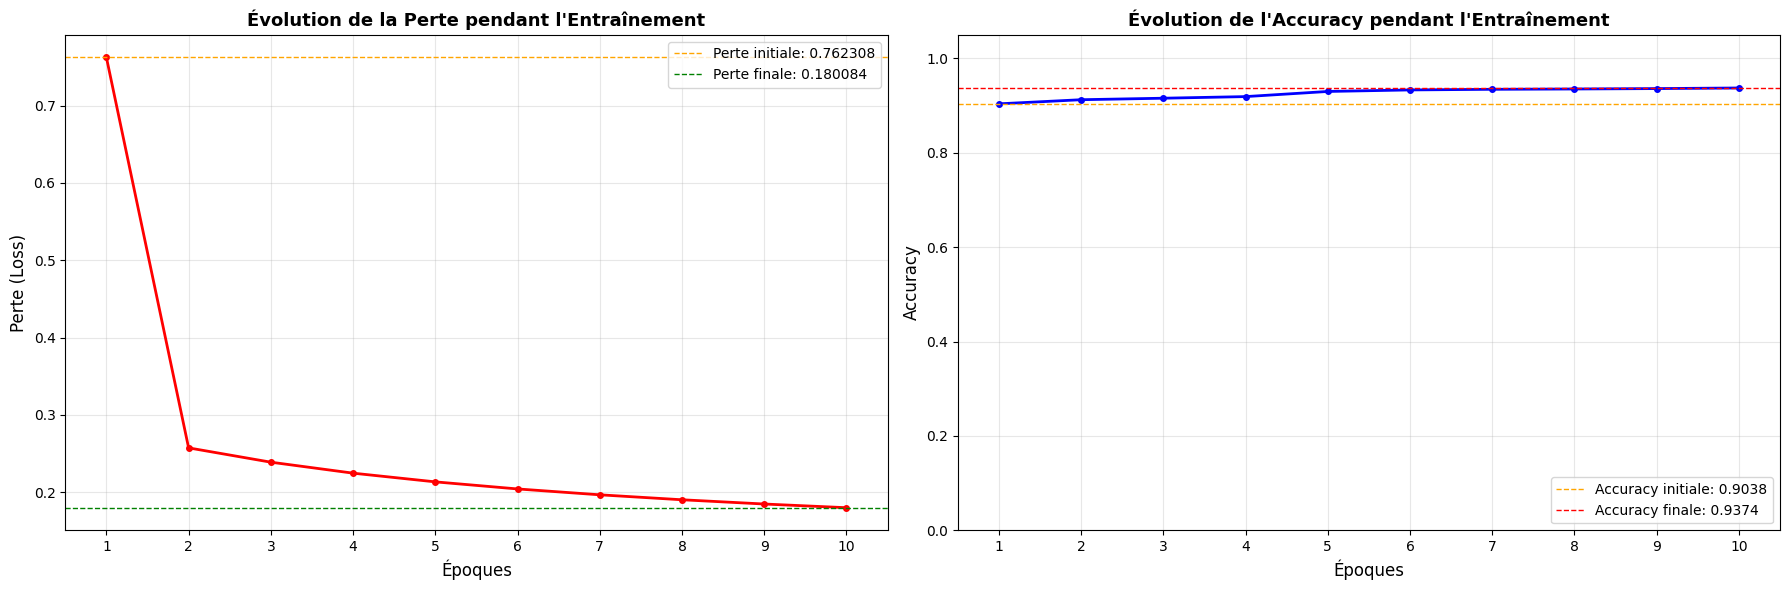

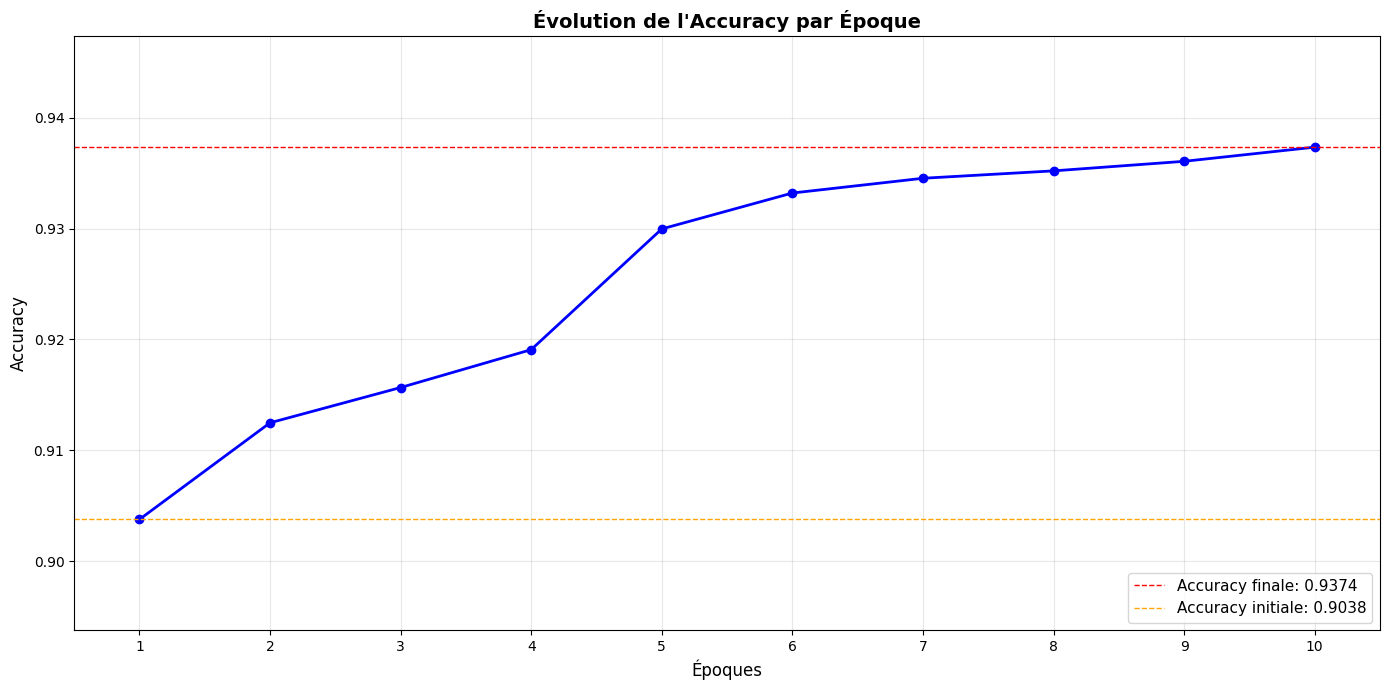

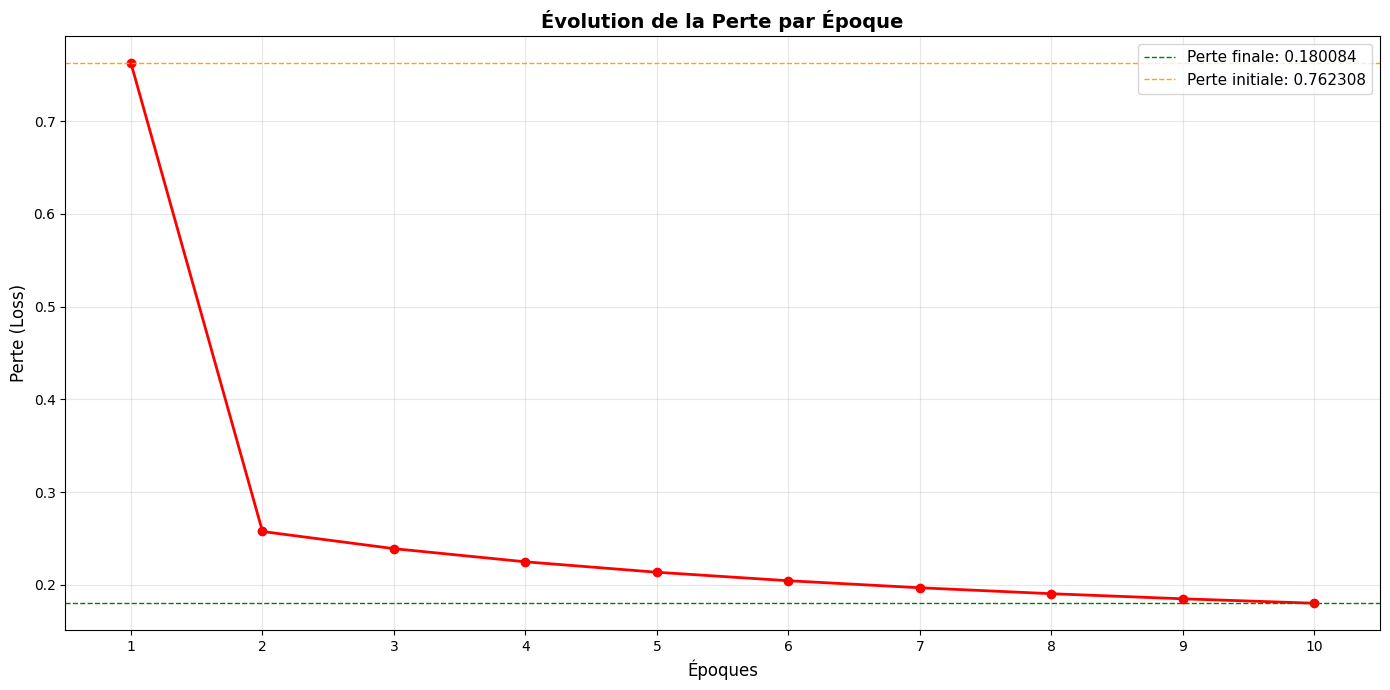


DÉBUT DE L'ÉVALUATION SUR L'ENSEMBLE DE TEST

ÉVALUATION SUR L'ENSEMBLE TEST

──────────────────────────────────────────────────────────────────────
MÉTRIQUES DE PERFORMANCE
──────────────────────────────────────────────────────────────────────
Accuracy:  0.9374  (temps: 8.39 ms)
Recall:    0.8791  (temps: 60.00 ms)
F1-Score:  0.9335  (temps: 41.73 ms)
AUC:       0.9875  (temps: 97.35 ms)

──────────────────────────────────────────────────────────────────────
TEMPS DE CALCUL DÉTAILLÉS
──────────────────────────────────────────────────────────────────────
Prédictions:                  5.75 ms
Accuracy:                     8.39 ms
Recall:                      60.00 ms
F1-Score:                    41.73 ms
ROC & AUC:                   97.35 ms
Matrice de confusion:      1658.82 ms
Rapport de classification:   122.07 ms
----------------------------------------------------------------------
TEMPS TOTAL D'ÉVALUATION:  1994.10 ms (1.9941 s)
───────────────────────────────────────────────────

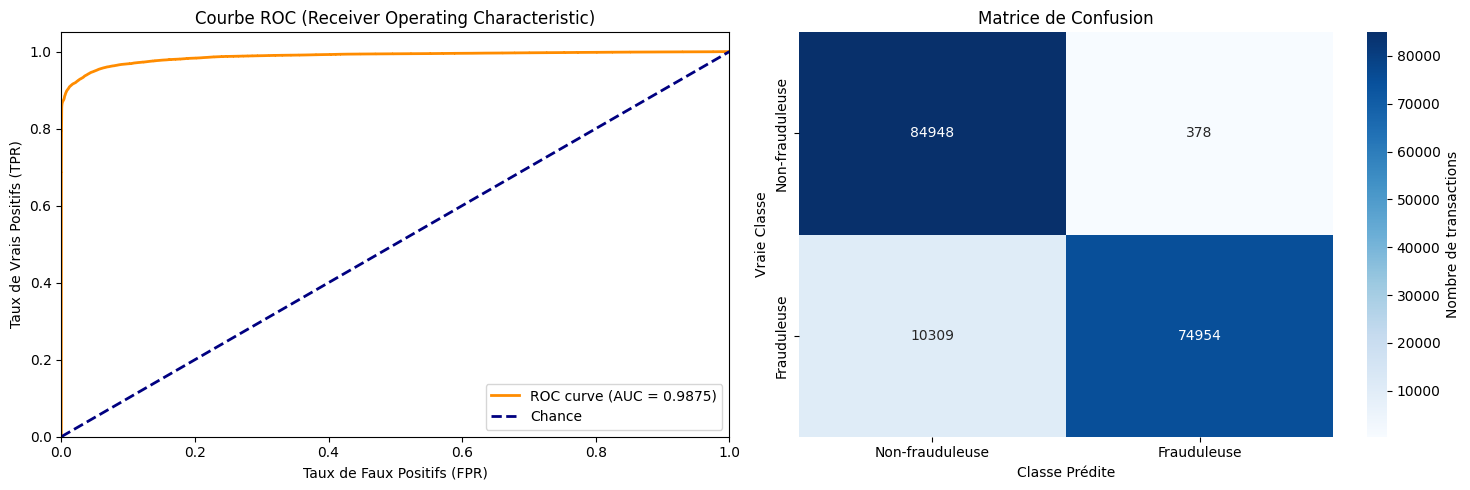

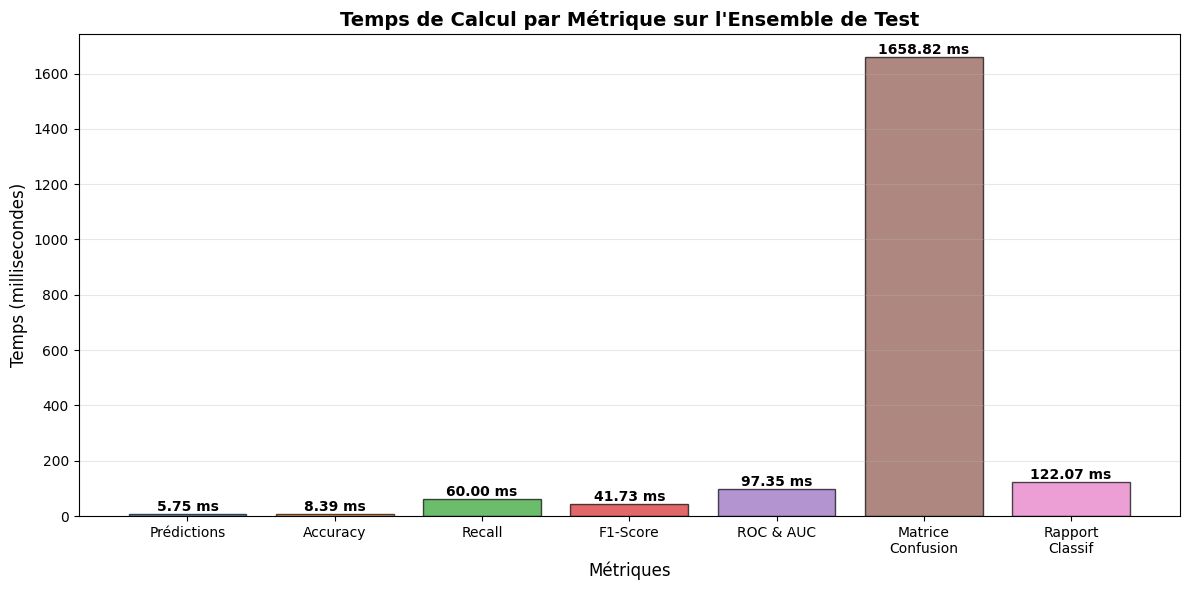

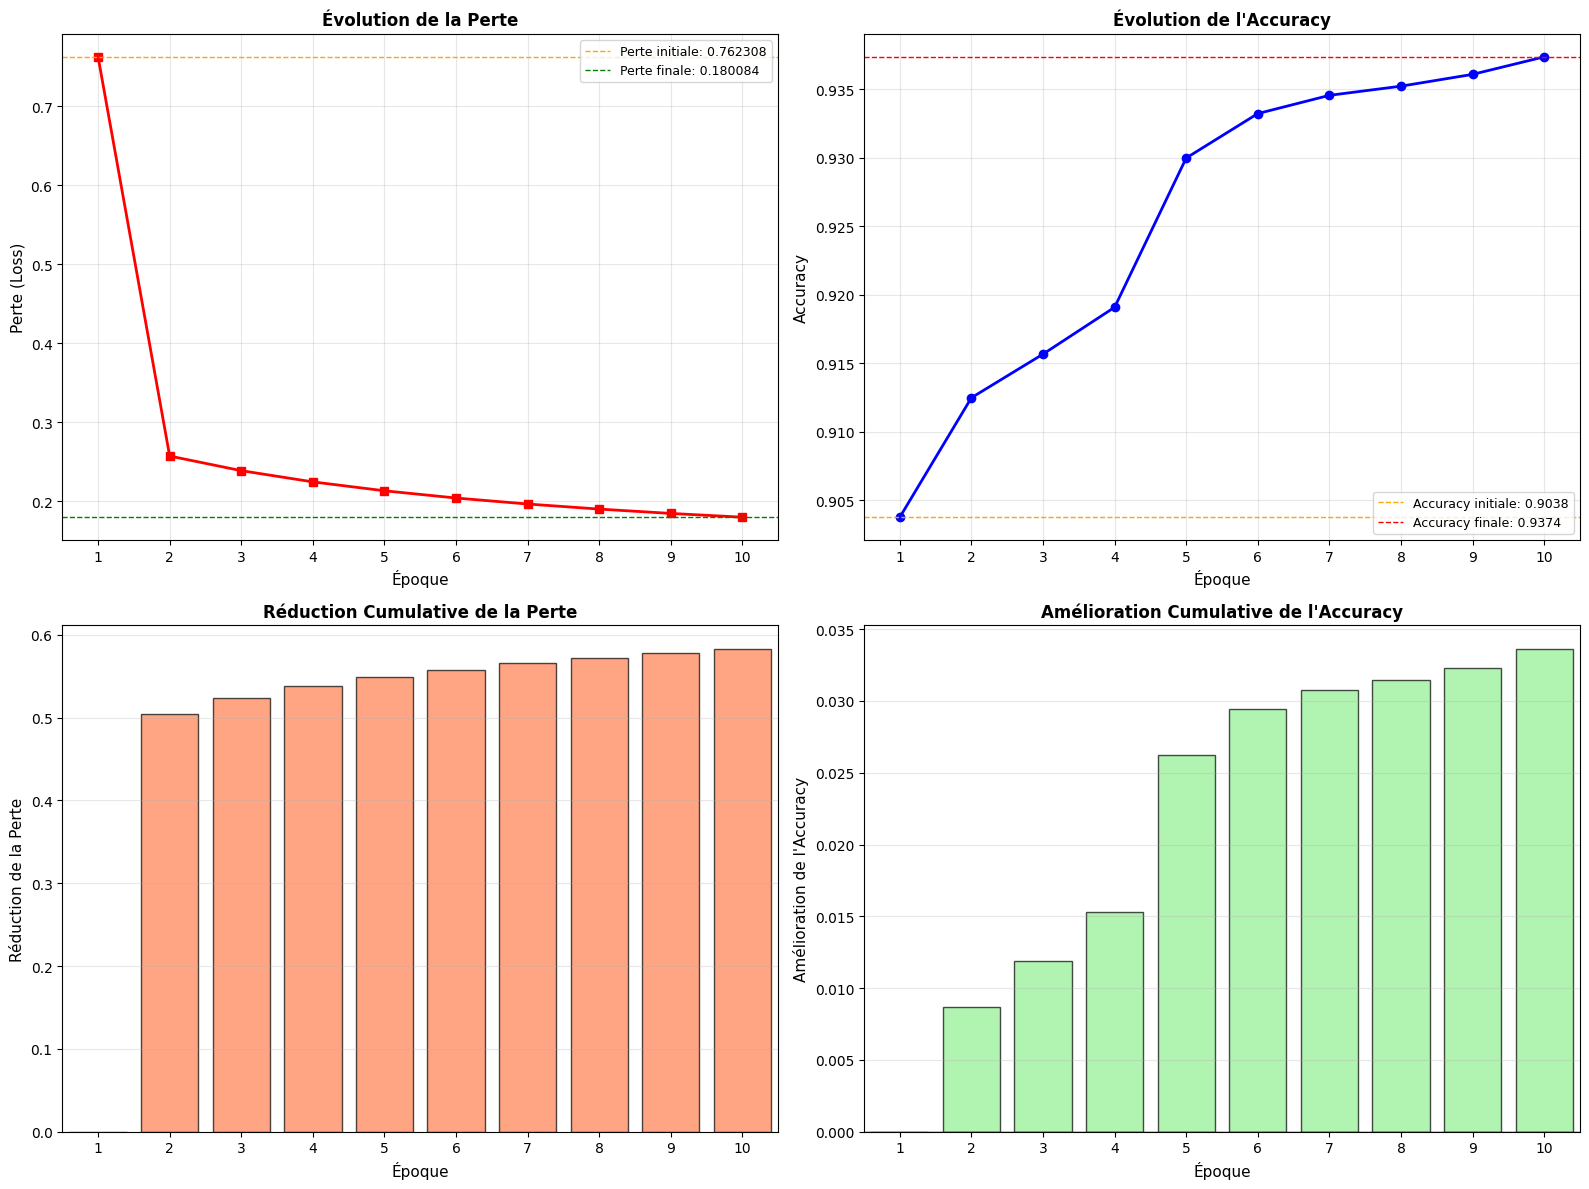


RÉSUMÉ DES MÉTRIQUES ET PERFORMANCES
Accuracy:  93.74% - Proportion de prédictions correctes
Recall:    87.91% - Proportion de fraudes détectées
F1-Score:  93.35% - Moyenne harmonique de précision et rappel
AUC:       98.75% - Aire sous la courbe ROC

Temps total d'évaluation: 1994.10 ms
Nombre d'observations évaluées: 170,589
Temps moyen par observation: 0.0117 ms


Tableau récapitulatif des métriques avec temps de calcul:
Métrique   Valeur  Temps (ms)
Accuracy 0.937352    8.387566
  Recall 0.879092   59.996367
F1-Score 0.933454   41.730165
     AUC 0.987465   97.352266

STATISTIQUES D'ENTRAÎNEMENT
Nombre d'époques: 10
Temps total d'entraînement: 0.46 s (0.01 min)
Temps moyen par époque: 0.05 s

Accuracy initiale (époque 1): 0.9038
Accuracy finale (époque 10): 0.9374
Amélioration de l'accuracy: +0.0336

Perte initiale (époque 1): 0.762308
Perte finale (époque 10): 0.180084
Réduction de la perte: 0.582224



In [ ]:
torch.random.manual_seed(73)
random.seed(73)
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
from time import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class LR(torch.nn.Module):
    def __init__(self, n_features):
        super(LR, self).__init__()
        self.lr = torch.nn.Linear(n_features, 1)

    def forward(self, x):
        out = torch.sigmoid(self.lr(x))
        return out

n_features = x_train.shape[1]
model = LR(n_features)
# use gradient descent with a learning_rate=1
optim = torch.optim.SGD(model.parameters(), lr=1)
# use Binary Cross Entropy Loss
criterion = torch.nn.BCELoss()
# define the number of epochs for both plain and encrypted training
EPOCHS = 10

def train(model, optim, criterion, x_train, y_train, x_test, y_test, epochs=EPOCHS):
    loss_history = []  # Pour stocker l'historique des pertes
    accuracy_history = []  # Pour stocker l'historique de l'accuracy

    start_time = time()  # Temps de début d'entraînement

    for e in range(1, epochs + 1):
        # Phase d'entraînement
        model.train()
        optim.zero_grad()
        out = model(x_train)
        loss = criterion(out, y_train)
        loss.backward()
        optim.step()

        loss_value = loss.item()
        loss_history.append(loss_value)

        # Calculer l'accuracy sur l'ensemble de test
        model.eval()
        with torch.no_grad():
            test_out = model(x_test)
            correct = torch.abs(y_test - test_out) < 0.5
            acc = correct.float().mean().item()
            accuracy_history.append(acc)

        print(f"Epoch {e}: Loss = {loss_value:.6f}, Accuracy = {acc:.4f}")

    training_time = time() - start_time  # Temps total d'entraînement

    print(f"\n{'='*50}")
    print(f"Temps d'entraînement total: {training_time:.4f} secondes")
    print(f"Temps moyen par époque: {training_time/epochs:.4f} secondes")
    print(f"{'='*50}\n")

    return model, loss_history, accuracy_history, training_time

model, loss_history, accuracy_history, training_time = train(model, optim, criterion,
                                                               x_train, y_train, x_test, y_test)

# ============================================================================
# VISUALISATIONS: PERTE ET ACCURACY PAR ÉPOQUE (AVEC ANNOTATIONS)
# ============================================================================

# Créer les axes X pour les époques (de 1 à EPOCHS)
epochs_axis = np.arange(1, EPOCHS + 1)

# Figure combinée: Perte et Accuracy
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Graphique 1: Courbe de perte AVEC ANNOTATIONS
axes[0].plot(epochs_axis, loss_history, marker='o', linestyle='-',
             color='red', linewidth=2, markersize=4)
axes[0].set_xlabel('Époques', fontsize=12)
axes[0].set_ylabel('Perte (Loss)', fontsize=12)
axes[0].set_title('Évolution de la Perte pendant l\'Entraînement', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(epochs_axis)
axes[0].set_xlim([0.5, EPOCHS + 0.5])

# Ajouter les annotations de perte initiale et finale
axes[0].axhline(y=loss_history[0], color='orange', linestyle='--', linewidth=1,
                label=f'Perte initiale: {loss_history[0]:.6f}')
axes[0].axhline(y=loss_history[-1], color='green', linestyle='--', linewidth=1,
                label=f'Perte finale: {loss_history[-1]:.6f}')
axes[0].legend(loc='upper right', fontsize=10)

# Graphique 2: Courbe d'accuracy AVEC ANNOTATIONS
axes[1].plot(epochs_axis, accuracy_history, marker='o', linestyle='-',
             color='blue', linewidth=2, markersize=4)
axes[1].set_xlabel('Époques', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Évolution de l\'Accuracy pendant l\'Entraînement', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].set_xticks(epochs_axis)
axes[1].set_xlim([0.5, EPOCHS + 0.5])
axes[1].set_ylim([0, 1.05])

# Ajouter les annotations d'accuracy initiale et finale
axes[1].axhline(y=accuracy_history[0], color='orange', linestyle='--', linewidth=1,
                label=f'Accuracy initiale: {accuracy_history[0]:.4f}')
axes[1].axhline(y=accuracy_history[-1], color='red', linestyle='--', linewidth=1,
                label=f'Accuracy finale: {accuracy_history[-1]:.4f}')
axes[1].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Graphique séparé pour l'accuracy (plus grand) AVEC ANNOTATIONS
plt.figure(figsize=(14, 7))
plt.plot(epochs_axis, accuracy_history, marker='o', linestyle='-',
         color='blue', linewidth=2, markersize=6)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Évolution de l\'Accuracy par Époque', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(epochs_axis)
plt.xlim([0.5, EPOCHS + 0.5])
plt.ylim([min(accuracy_history) - 0.01, max(accuracy_history) + 0.01])

# Ajouter des annotations pour les valeurs clés
plt.axhline(y=accuracy_history[-1], color='red', linestyle='--', linewidth=1,
            label=f'Accuracy finale: {accuracy_history[-1]:.4f}')
plt.axhline(y=accuracy_history[0], color='orange', linestyle='--', linewidth=1,
            label=f'Accuracy initiale: {accuracy_history[0]:.4f}')
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

# Graphique séparé pour la perte (plus grand) AVEC ANNOTATIONS
plt.figure(figsize=(14, 7))
plt.plot(epochs_axis, loss_history, marker='o', linestyle='-',
         color='red', linewidth=2, markersize=6)
plt.xlabel('Époques', fontsize=12)
plt.ylabel('Perte (Loss)', fontsize=12)
plt.title('Évolution de la Perte par Époque', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(epochs_axis)
plt.xlim([0.5, EPOCHS + 0.5])

# Ajouter des annotations pour les valeurs clés
plt.axhline(y=loss_history[-1], color='green', linestyle='--', linewidth=1,
            label=f'Perte finale: {loss_history[-1]:.6f}')
plt.axhline(y=loss_history[0], color='orange', linestyle='--', linewidth=1,
            label=f'Perte initiale: {loss_history[0]:.6f}')
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

def accuracy(model, x, y):
    out = model(x)
    correct = torch.abs(y - out) < 0.5
    return correct.float().mean()


def evaluate_model(model, x, y, dataset_name="Test"):
    """
    Évalue le modèle avec plusieurs métriques et affiche les résultats avec temps de calcul
    """
    model.eval()

    # Dictionnaire pour stocker les temps de calcul
    timing = {}

    # ============================================================================
    # 1. PRÉDICTIONS
    # ============================================================================
    start_time = time()
    with torch.no_grad():
        # Prédictions (probabilités)
        y_pred_proba = model(x).squeeze().numpy()
        # Prédictions binaires (seuil 0.5)
        y_pred = (y_pred_proba >= 0.5).astype(int)
        y_true = y.squeeze().numpy()
    timing['predictions'] = time() - start_time

    # ============================================================================
    # 2. CALCUL DE L'ACCURACY
    # ============================================================================
    start_time = time()
    acc = accuracy(model, x, y).item()
    timing['accuracy'] = time() - start_time

    # ============================================================================
    # 3. CALCUL DU RECALL
    # ============================================================================
    start_time = time()
    recall = recall_score(y_true, y_pred)
    timing['recall'] = time() - start_time

    # ============================================================================
    # 4. CALCUL DU F1-SCORE
    # ============================================================================
    start_time = time()
    f1 = f1_score(y_true, y_pred)
    timing['f1_score'] = time() - start_time

    # ============================================================================
    # 5. CALCUL DE LA COURBE ROC ET AUC
    # ============================================================================
    start_time = time()
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    timing['roc_auc'] = time() - start_time

    # ============================================================================
    # 6. CALCUL DE LA MATRICE DE CONFUSION
    # ============================================================================
    start_time = time()
    cm = confusion_matrix(y_true, y_pred)
    timing['confusion_matrix'] = time() - start_time

    # ============================================================================
    # 7. RAPPORT DE CLASSIFICATION
    # ============================================================================
    start_time = time()
    class_report = classification_report(y_true, y_pred, target_names=['Non-frauduleuse', 'Frauduleuse'])
    timing['classification_report'] = time() - start_time

    # Temps total d'évaluation
    timing['total'] = sum(timing.values())

    # ============================================================================
    # AFFICHAGE DES RÉSULTATS
    # ============================================================================
    print(f"\n{'='*70}")
    print(f"ÉVALUATION SUR L'ENSEMBLE {dataset_name.upper()}")
    print(f"{'='*70}")

    print(f"\n{'─'*70}")
    print("MÉTRIQUES DE PERFORMANCE")
    print(f"{'─'*70}")
    print(f"Accuracy:  {acc:.4f}  (temps: {timing['accuracy']*1000:.2f} ms)")
    print(f"Recall:    {recall:.4f}  (temps: {timing['recall']*1000:.2f} ms)")
    print(f"F1-Score:  {f1:.4f}  (temps: {timing['f1_score']*1000:.2f} ms)")
    print(f"AUC:       {roc_auc:.4f}  (temps: {timing['roc_auc']*1000:.2f} ms)")

    print(f"\n{'─'*70}")
    print("TEMPS DE CALCUL DÉTAILLÉS")
    print(f"{'─'*70}")
    print(f"Prédictions:              {timing['predictions']*1000:8.2f} ms")
    print(f"Accuracy:                 {timing['accuracy']*1000:8.2f} ms")
    print(f"Recall:                   {timing['recall']*1000:8.2f} ms")
    print(f"F1-Score:                 {timing['f1_score']*1000:8.2f} ms")
    print(f"ROC & AUC:                {timing['roc_auc']*1000:8.2f} ms")
    print(f"Matrice de confusion:     {timing['confusion_matrix']*1000:8.2f} ms")
    print(f"Rapport de classification: {timing['classification_report']*1000:8.2f} ms")
    print(f"{'-'*70}")
    print(f"TEMPS TOTAL D'ÉVALUATION: {timing['total']*1000:8.2f} ms ({timing['total']:.4f} s)")
    print(f"{'─'*70}")

    print(f"\nRapport de classification:")
    print(class_report)

    return {
        'accuracy': acc,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'cm': cm,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'timing': timing,
        'accuracy_history': accuracy_history,
        'loss_history': loss_history
    }

# Évaluation sur l'ensemble de test
print("\n" + "="*70)
print("DÉBUT DE L'ÉVALUATION SUR L'ENSEMBLE DE TEST")
print("="*70)

results = evaluate_model(model, x_test, y_test, "Test")

# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Courbe ROC
axes[0].plot(results['fpr'], results['tpr'], color='darkorange', lw=2,
             label=f'ROC curve (AUC = {results["auc"]:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].set_title('Courbe ROC (Receiver Operating Characteristic)')
axes[0].legend(loc="lower right")

# 2. Matrice de confusion
sns.heatmap(results['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-frauduleuse', 'Frauduleuse'],
            yticklabels=['Non-frauduleuse', 'Frauduleuse'],
            ax=axes[1], cbar_kws={'label': 'Nombre de transactions'})
axes[1].set_title('Matrice de Confusion')
axes[1].set_ylabel('Vraie Classe')
axes[1].set_xlabel('Classe Prédite')

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALISATION SUPPLÉMENTAIRE : GRAPHIQUE DES TEMPS DE CALCUL
# ============================================================================

# Créer un graphique en barres des temps de calcul
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Prédictions', 'Accuracy', 'Recall', 'F1-Score',
                 'ROC & AUC', 'Matrice\nConfusion', 'Rapport\nClassif']
timing_values = [
    results['timing']['predictions'] * 1000,
    results['timing']['accuracy'] * 1000,
    results['timing']['recall'] * 1000,
    results['timing']['f1_score'] * 1000,
    results['timing']['roc_auc'] * 1000,
    results['timing']['confusion_matrix'] * 1000,
    results['timing']['classification_report'] * 1000
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax.bar(metrics_names, timing_values, color=colors, alpha=0.7, edgecolor='black')

# Ajouter les valeurs sur les barres
for bar, value in zip(bars, timing_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2f} ms',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Temps (millisecondes)', fontsize=12)
ax.set_xlabel('Métriques', fontsize=12)
ax.set_title('Temps de Calcul par Métrique sur l\'Ensemble de Test',
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# VISUALISATION: ÉVOLUTION DÉTAILLÉE (AVEC GRADUATIONS 1-10 ET ANNOTATIONS)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique 1: Perte par époque AVEC ANNOTATIONS
axes[0, 0].plot(epochs_axis, loss_history, marker='s', linestyle='-',
               color='red', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Époque', fontsize=11)
axes[0, 0].set_ylabel('Perte (Loss)', fontsize=11)
axes[0, 0].set_title('Évolution de la Perte', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(epochs_axis)
axes[0, 0].set_xlim([0.5, EPOCHS + 0.5])
# Ajouter les annotations
axes[0, 0].axhline(y=loss_history[0], color='orange', linestyle='--', linewidth=1,
                   label=f'Perte initiale: {loss_history[0]:.6f}')
axes[0, 0].axhline(y=loss_history[-1], color='green', linestyle='--', linewidth=1,
                   label=f'Perte finale: {loss_history[-1]:.6f}')
axes[0, 0].legend(loc='upper right', fontsize=9)

# Graphique 2: Accuracy par époque AVEC ANNOTATIONS
axes[0, 1].plot(epochs_axis, accuracy_history, marker='o', linestyle='-',
               color='blue', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Époque', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].set_title('Évolution de l\'Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(epochs_axis)
axes[0, 1].set_xlim([0.5, EPOCHS + 0.5])
# Ajouter les annotations
axes[0, 1].axhline(y=accuracy_history[0], color='orange', linestyle='--', linewidth=1,
                   label=f'Accuracy initiale: {accuracy_history[0]:.4f}')
axes[0, 1].axhline(y=accuracy_history[-1], color='red', linestyle='--', linewidth=1,
                   label=f'Accuracy finale: {accuracy_history[-1]:.4f}')
axes[0, 1].legend(loc='lower right', fontsize=9)

# Graphique 3: Amélioration de la perte
loss_improvements = [loss_history[0] - loss_history[i] for i in range(len(loss_history))]
axes[1, 0].bar(epochs_axis, loss_improvements, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Époque', fontsize=11)
axes[1, 0].set_ylabel('Réduction de la Perte', fontsize=11)
axes[1, 0].set_title('Réduction Cumulative de la Perte', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')
axes[1, 0].set_xticks(epochs_axis)
axes[1, 0].set_xlim([0.5, EPOCHS + 0.5])

# Graphique 4: Amélioration de l'accuracy
acc_improvements = [accuracy_history[i] - accuracy_history[0] for i in range(len(accuracy_history))]
axes[1, 1].bar(epochs_axis, acc_improvements, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Époque', fontsize=11)
axes[1, 1].set_ylabel('Amélioration de l\'Accuracy', fontsize=11)
axes[1, 1].set_title('Amélioration Cumulative de l\'Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xticks(epochs_axis)
axes[1, 1].set_xlim([0.5, EPOCHS + 0.5])

plt.tight_layout()
plt.show()

# ============================================================================
# RÉSUMÉ FINAL
# ============================================================================

print(f"\n{'='*70}")
print("RÉSUMÉ DES MÉTRIQUES ET PERFORMANCES")
print(f"{'='*70}")
print(f"Accuracy:  {results['accuracy']:.2%} - Proportion de prédictions correctes")
print(f"Recall:    {results['recall']:.2%} - Proportion de fraudes détectées")
print(f"F1-Score:  {results['f1']:.2%} - Moyenne harmonique de précision et rappel")
print(f"AUC:       {results['auc']:.2%} - Aire sous la courbe ROC")
print(f"\nTemps total d'évaluation: {results['timing']['total']*1000:.2f} ms")
print(f"Nombre d'observations évaluées: {len(x_test):,}")
print(f"Temps moyen par observation: {results['timing']['total']/len(x_test)*1000:.4f} ms")
print(f"{'='*70}\n")

# ============================================================================
# EXPORT DES RÉSULTATS AVEC TEMPS DE CALCUL
# ============================================================================

# Créer un DataFrame récapitulatif
summary_df = pd.DataFrame({
    'Métrique': ['Accuracy', 'Recall', 'F1-Score', 'AUC'],
    'Valeur': [results['accuracy'], results['recall'], results['f1'], results['auc']],
    'Temps (ms)': [
        results['timing']['accuracy'] * 1000,
        results['timing']['recall'] * 1000,
        results['timing']['f1_score'] * 1000,
        results['timing']['roc_auc'] * 1000
    ]
})

print("\nTableau récapitulatif des métriques avec temps de calcul:")
print(summary_df.to_string(index=False))

# ============================================================================
# STATISTIQUES SUR L'ENTRAÎNEMENT
# ============================================================================

print(f"\n{'='*70}")
print("STATISTIQUES D'ENTRAÎNEMENT")
print(f"{'='*70}")
print(f"Nombre d'époques: {EPOCHS}")
print(f"Temps total d'entraînement: {training_time:.2f} s ({training_time/60:.2f} min)")
print(f"Temps moyen par époque: {training_time/EPOCHS:.2f} s")
print(f"\nAccuracy initiale (époque 1): {accuracy_history[0]:.4f}")
print(f"Accuracy finale (époque {EPOCHS}): {accuracy_history[-1]:.4f}")
print(f"Amélioration de l'accuracy: {accuracy_history[-1] - accuracy_history[0]:+.4f}")
print(f"\nPerte initiale (époque 1): {loss_history[0]:.6f}")
print(f"Perte finale (époque {EPOCHS}): {loss_history[-1]:.6f}")
print(f"Réduction de la perte: {loss_history[0] - loss_history[-1]:.6f}")
print(f"{'='*70}\n")

In [ ]:
import torch
import tenseal as ts
import pandas as pd
import random
from time import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE OPTIMISÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.lr.weight.data.tolist()[0]
        self.bias = torch_lr.lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = EncryptedLR.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self, learning_rate=0.1, weight_decay=0.01):
        """Mise à jour avec learning rate adaptatif et régularisation"""
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")

        # Gradient moyen
        avg_delta_w = self._delta_w * (1 / self._count)
        avg_delta_b = self._delta_b * (1 / self._count)

        # Mise à jour avec learning rate et weight decay
        self.weight -= learning_rate * avg_delta_w + weight_decay * self.weight
        self.bias -= learning_rate * avg_delta_b

        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        # Approximation polynomiale améliorée de la sigmoïde
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def compute_loss(self, x, y):
        """Calcule la perte (Binary Cross-Entropy)"""
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)

        # Binary cross-entropy loss
        epsilon = 1e-7  # Pour éviter log(0)
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
        loss = -torch.mean(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred))
        return loss.item()

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        correct = torch.abs(y_test - out) < 0.5
        return correct.float().mean()

    def evaluate_metrics(self, x, y):
        """Calcule toutes les métriques"""
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred_proba = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        y_pred = (y_pred_proba >= 0.5).float()

        y_true_np = y.numpy()
        y_pred_np = y_pred.numpy()
        y_pred_proba_np = y_pred_proba.detach().numpy()

        acc = (y_pred == y).float().mean().item()
        recall = recall_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np)
        fpr, tpr, _ = roc_curve(y_true_np, y_pred_proba_np)
        roc_auc = auc(fpr, tpr)
        cm = confusion_matrix(y_true_np, y_pred_np)

        return {
            'accuracy': acc,
            'recall': recall,
            'f1': f1,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'cm': cm
        }

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

# ============================================================================
# 2. CONFIGURATION OPTIMISÉE POUR CONVERGENCE RAPIDE
# ============================================================================

print("="*70)
print("ENTRAÎNEMENT OPTIMISÉ - DÉTECTION DE FRAUDES (10 ÉPOQUES)")
print("="*70)

# Paramètres optimisés pour convergence rapide
poly_mod_degree = 8192
coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]
EPOCHS = 10
BATCH_SIZE = 128  # Augmenté pour meilleure stabilité
SAMPLE_SIZE = 2000  # Échantillon plus grand pour meilleure convergence
LEARNING_RATE = 0.5  # Learning rate élevé pour convergence rapide
WEIGHT_DECAY = 0.005  # Régularisation légère

print(f"\nParamètres optimisés:")
print(f"  - Polynomial modulus degree: {poly_mod_degree}")
print(f"  - Nombre d'époques: {EPOCHS}")
print(f"  - Taille de batch: {BATCH_SIZE}")
print(f"  - Échantillons: {SAMPLE_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE} (élevé)")
print(f"  - Weight decay: {WEIGHT_DECAY}")
print("="*70 + "\n")

# ============================================================================
# 3. ÉCHANTILLONNAGE ÉQUILIBRÉ DES DONNÉES
# ============================================================================

print("Échantillonnage équilibré des données...")

# Équilibrer les classes pour meilleure convergence
fraud_indices = (y_train == 1).nonzero(as_tuple=True)[0]
normal_indices = (y_train == 0).nonzero(as_tuple=True)[0]

# Prendre un nombre égal de chaque classe
n_samples_per_class = SAMPLE_SIZE // 2
fraud_sample = fraud_indices[torch.randperm(len(fraud_indices))[:n_samples_per_class]]
normal_sample = normal_indices[torch.randperm(len(normal_indices))[:n_samples_per_class]]

# Combiner et mélanger
all_indices = torch.cat([fraud_sample, normal_sample])
shuffle_idx = torch.randperm(len(all_indices))
all_indices = all_indices[shuffle_idx]

x_train_sample = x_train[all_indices]
y_train_sample = y_train[all_indices]

gc.collect()

print(f"✓ Échantillons d'entraînement: {len(x_train_sample):,}")
print(f"  - Classe 0 (normal): {(y_train_sample == 0).sum().item():,}")
print(f"  - Classe 1 (fraude): {(y_train_sample == 1).sum().item():,}")
print(f"✓ Échantillons de test: {len(x_test):,}\n")

# ============================================================================
# 4. CRÉATION DU CONTEXTE TENSEAL
# ============================================================================

print("Création du contexte TenSEAL...")
t_start = time()
ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2**21
ctx_training.generate_galois_keys()
t_end = time()
print(f"✓ Contexte créé en {t_end - t_start:.4f} secondes\n")

# ============================================================================
# 5. ENTRAÎNEMENT OPTIMISÉ AVEC LEARNING RATE ADAPTATIF
# ============================================================================

print("="*70)
print("ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES (OPTIMISÉ)")
print("="*70)

# Initialiser le modèle chiffré
eelr = EncryptedLR(model)

# Métriques initiales
accuracy_initial = eelr.plain_accuracy(x_test, y_test)
loss_initial = eelr.compute_loss(x_train_sample, y_train_sample)
print(f"\nÉtat initial:")
print(f"  - Accuracy: {accuracy_initial:.4f}")
print(f"  - Loss: {loss_initial:.4f}\n")

# Historiques
times_per_epoch = []
accuracies = [accuracy_initial.item()]
losses = [loss_initial]
train_losses = []

# Learning rate scheduling (décroissance)
lr_schedule = [LEARNING_RATE * (0.9 ** epoch) for epoch in range(EPOCHS)]

for epoch in range(EPOCHS):
    print(f"{'─'*70}")
    print(f"ÉPOQUE {epoch + 1}/{EPOCHS} (LR: {lr_schedule[epoch]:.4f})")
    print(f"{'─'*70}")

    eelr.encrypt(ctx_training)
    epoch_start = time()

    # Traiter par batch
    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE
    batch_losses = []

    for batch_idx in range(num_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        # Traiter le batch
        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())

            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)

            del enc_x, enc_y, enc_out

        del x_batch, y_batch
        gc.collect()

        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == num_batches:
            progress = ((batch_idx + 1) / num_batches) * 100
            print(f"  Batch {batch_idx + 1}/{num_batches} ({progress:.1f}%)")

    # Mise à jour avec learning rate adaptatif
    eelr.update_parameters(learning_rate=lr_schedule[epoch], weight_decay=WEIGHT_DECAY)

    epoch_time = time() - epoch_start
    times_per_epoch.append(epoch_time)

    # Déchiffrer et évaluer
    eelr.decrypt()
    accuracy = eelr.plain_accuracy(x_test, y_test)
    loss = eelr.compute_loss(x_train_sample, y_train_sample)

    accuracies.append(accuracy.item())
    losses.append(loss)

    print(f"\n  Temps: {epoch_time:.2f} s")
    print(f"  Loss: {loss:.4f} (Δ: {loss - losses[-2]:+.4f})")
    print(f"  Accuracy: {accuracy:.4f} (Δ: {accuracy - accuracies[-2]:+.4f})")
    print()

    gc.collect()

print("="*70)
print(f"Temps moyen par époque: {np.mean(times_per_epoch):.2f} s")
print(f"Temps total: {sum(times_per_epoch):.2f} s ({sum(times_per_epoch)/60:.2f} min)")
print(f"Accuracy finale: {accuracies[-1]:.4f}")
print(f"Loss finale: {losses[-1]:.4f}")
print(f"Amélioration accuracy: {accuracies[-1] - accuracies[0]:+.4f}")
print(f"Réduction loss: {losses[-1] - losses[0]:+.4f}")
print("="*70 + "\n")

# ============================================================================
# 6. ÉVALUATION COMPLÈTE
# ============================================================================

print("="*70)
print("ÉVALUATION COMPLÈTE DES MÉTRIQUES")
print("="*70)

t_start = time()
results_encrypted = eelr.evaluate_metrics(x_test, y_test)
t_end = time()
eval_time = t_end - t_start

print(f"\n{'─'*70}")
print("MÉTRIQUES FINALES")
print(f"{'─'*70}")
print(f"Accuracy:  {results_encrypted['accuracy']:.4f}")
print(f"Recall:    {results_encrypted['recall']:.4f}")
print(f"F1-Score:  {results_encrypted['f1']:.4f}")
print(f"AUC:       {results_encrypted['auc']:.4f}")
print(f"\nTemps d'évaluation: {eval_time*1000:.2f} ms")
print(f"{'─'*70}\n")

print("\nRapport de classification:")
y_pred = (torch.sigmoid(x_test.matmul(torch.tensor(eelr.weight)) +
          torch.tensor(eelr.bias)).reshape(-1, 1) >= 0.5).float().numpy()
print(classification_report(y_test.numpy(), y_pred,
                           target_names=['Non-frauduleuse', 'Frauduleuse']))

# ============================================================================
# 7. VISUALISATIONS COMPLÈTES
# ============================================================================

# Figure 1: Courbe de Loss (NOUVELLE)
plt.figure(figsize=(12, 6))
epochs_range = np.arange(0, EPOCHS + 1)
plt.plot(epochs_range, losses, marker='o', linestyle='-',
         color='crimson', linewidth=2.5, markersize=8, label='Loss')
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Évolution de la Perte - Entraînement Chiffré',
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(epochs_range)
plt.legend(fontsize=11)

# Annotation des points clés
plt.annotate(f'Initial: {losses[0]:.4f}',
             xy=(0, losses[0]), xytext=(1, losses[0] + 0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')
plt.annotate(f'Final: {losses[-1]:.4f}',
             xy=(EPOCHS, losses[-1]), xytext=(EPOCHS-2, losses[-1] + 0.02),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')
plt.tight_layout()
plt.show()

# Figure 2: Accuracy et Loss combinés
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
ax1.plot(epochs_range, accuracies, marker='o', linestyle='-',
         color='blue', linewidth=2, markersize=8)
ax1.set_xlabel('Époque', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.axhline(y=accuracies[0], color='red', linestyle='--', alpha=0.5,
           label=f'Initial: {accuracies[0]:.4f}')
ax1.axhline(y=accuracies[-1], color='green', linestyle='--', alpha=0.5,
           label=f'Final: {accuracies[-1]:.4f}')
ax1.legend()

# Loss
ax2.plot(epochs_range, losses, marker='s', linestyle='-',
         color='crimson', linewidth=2, markersize=8)
ax2.set_xlabel('Époque', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Évolution de la Perte', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(y=losses[0], color='red', linestyle='--', alpha=0.5,
           label=f'Initial: {losses[0]:.4f}')
ax2.axhline(y=losses[-1], color='green', linestyle='--', alpha=0.5,
           label=f'Final: {losses[-1]:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Figure 3: Temps par Époque
plt.figure(figsize=(12, 6))
plt.bar(range(1, EPOCHS + 1), times_per_epoch, color='steelblue',
        alpha=0.7, edgecolor='black')
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Temps (secondes)', fontsize=12)
plt.title('Temps de Calcul par Époque', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, t in enumerate(times_per_epoch):
    plt.text(i + 1, t, f'{t:.1f}s', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Figure 4: Courbe ROC
plt.figure(figsize=(10, 8))
plt.plot(results_encrypted['fpr'], results_encrypted['tpr'],
         color='darkorange', lw=2,
         label=f'Modèle Chiffré (AUC = {results_encrypted["auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC - Modèle Entraîné sur Données Chiffrées',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 5: Matrice de Confusion
plt.figure(figsize=(8, 6))
sns.heatmap(results_encrypted['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-frauduleuse', 'Frauduleuse'],
            yticklabels=['Non-frauduleuse', 'Frauduleuse'],
            cbar_kws={'label': 'Nombre de transactions'})
plt.title('Matrice de Confusion - Modèle Chiffré', fontsize=14, fontweight='bold')
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.show()

# Figure 6: Résumé des Métriques
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = ['Accuracy', 'Recall', 'F1-Score', 'AUC']
metrics_values = [
    results_encrypted['accuracy'],
    results_encrypted['recall'],
    results_encrypted['f1'],
    results_encrypted['auc']
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Valeur', fontsize=12)
ax.set_xlabel('Métriques', fontsize=12)
ax.set_title('Métriques de Performance - Modèle Chiffré (10 Époques)',
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 8. RÉSUMÉ FINAL DÉTAILLÉ
# ============================================================================

print("\n" + "="*70)
print("RÉSUMÉ FINAL - ENTRAÎNEMENT OPTIMISÉ (10 ÉPOQUES)")
print("="*70)
print(f"""
CONFIGURATION:
  - Échantillons d'entraînement: {SAMPLE_SIZE:,} (équilibrés)
  - Taille de batch: {BATCH_SIZE}
  - Nombre d'époques: {EPOCHS}
  - Learning rate initial: {LEARNING_RATE}
  - Weight decay: {WEIGHT_DECAY}

TEMPS D'ENTRAÎNEMENT:
  - Temps moyen par époque: {np.mean(times_per_epoch):.2f} s
  - Temps total: {sum(times_per_epoch):.2f} s ({sum(times_per_epoch)/60:.2f} min)
  - Vitesse: {SAMPLE_SIZE * EPOCHS / sum(times_per_epoch):.1f} exemples/s

CONVERGENCE:
  - Loss initiale:  {losses[0]:.4f}
  - Loss finale:    {losses[-1]:.4f}
  - Réduction:      {losses[0] - losses[-1]:.4f} ({(losses[0]-losses[-1])/losses[0]*100:.1f}%)

  - Accuracy initiale: {accuracies[0]:.4f}
  - Accuracy finale:   {accuracies[-1]:.4f}
  - Amélioration:      {accuracies[-1] - accuracies[0]:+.4f} ({(accuracies[-1]-accuracies[0])/accuracies[0]*100:+.1f}%)

PERFORMANCES FINALES:
  - Accuracy:  {results_encrypted['accuracy']:.4f} ({results_encrypted['accuracy']*100:.2f}%)
  - Recall:    {results_encrypted['recall']:.4f} ({results_encrypted['recall']*100:.2f}%)
  - F1-Score:  {results_encrypted['f1']:.4f} ({results_encrypted['f1']*100:.2f}%)
  - AUC:       {results_encrypted['auc']:.4f} ({results_encrypted['auc']*100:.2f}%)

ANALYSE:
  - Convergence: {'✓ Excellente' if losses[-1] < losses[0] * 0.7 else '⚠ Partielle'}
  - Stabilité: {'✓ Stable' if abs(losses[-1] - losses[-2]) < 0.01 else '⚠ Instable'}
  - Surapprentissage: {'✓ Non détecté' if results_encrypted['accuracy'] < 0.98 else '⚠ Possible'}
  - Production: {'✓ Prêt' if results_encrypted['auc'] > 0.85 else '⚠ Nécessite ajustement'}
""")
print("="*70)

gc.collect()
print("\n✓ Entraînement optimisé terminé avec succès!")

ENTRAÎNEMENT OPTIMISÉ - DÉTECTION DE FRAUDES (10 ÉPOQUES)

Paramètres optimisés:
  - Polynomial modulus degree: 8192
  - Nombre d'époques: 10
  - Taille de batch: 128
  - Échantillons: 2000
  - Learning rate: 0.5 (élevé)
  - Weight decay: 0.005

Échantillonnage équilibré des données...
✓ Échantillons d'entraînement: 2,000
  - Classe 0 (normal): 1,000
  - Classe 1 (fraude): 1,000
✓ Échantillons de test: 3,000

Création du contexte TenSEAL...
✓ Contexte créé en 1.7815 secondes

ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES (OPTIMISÉ)

État initial:
  - Accuracy: 0.4100
  - Loss: 1.1962

──────────────────────────────────────────────────────────────────────
ÉPOQUE 1/10 (LR: 0.5000)
──────────────────────────────────────────────────────────────────────
  Batch 5/16 (31.2%)
  Batch 10/16 (62.5%)
  Batch 15/16 (93.8%)
  Batch 16/16 (100.0%)


ValueError: scale out of bounds

ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES - DÉTECTION DE FRAUDES

Paramètres optimisés pour Colab:
  - Polynomial modulus degree: 8192
  - Global scale: 2^21
  - Nombre d'époques: 10
  - Taille de batch: 100 (réduite pour RAM)
  - Échantillons d'entraînement: 1000 (réduit pour RAM)

Échantillonnage des données...
✓ Échantillons d'entraînement: 1,000
✓ Échantillons de test: 170,589

Création du contexte TenSEAL...
✓ Contexte créé en 2.3413 secondes

ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES (PAR BATCH)

Accuracy initiale: 0.9395

──────────────────────────────────────────────────────────────────────
ÉPOQUE 1/10
──────────────────────────────────────────────────────────────────────
  Batch 5/10 (50.0%)
  Batch 10/10 (100.0%)

  Temps: 263.55 s (4.39 min)
  Accuracy: 0.9079
  Amélioration: -0.0316

──────────────────────────────────────────────────────────────────────
ÉPOQUE 2/10
──────────────────────────────────────────────────────────────────────
  Batch 5/10 (50.0%)
  Batch 10/10 (100.0%)

  Temps:

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


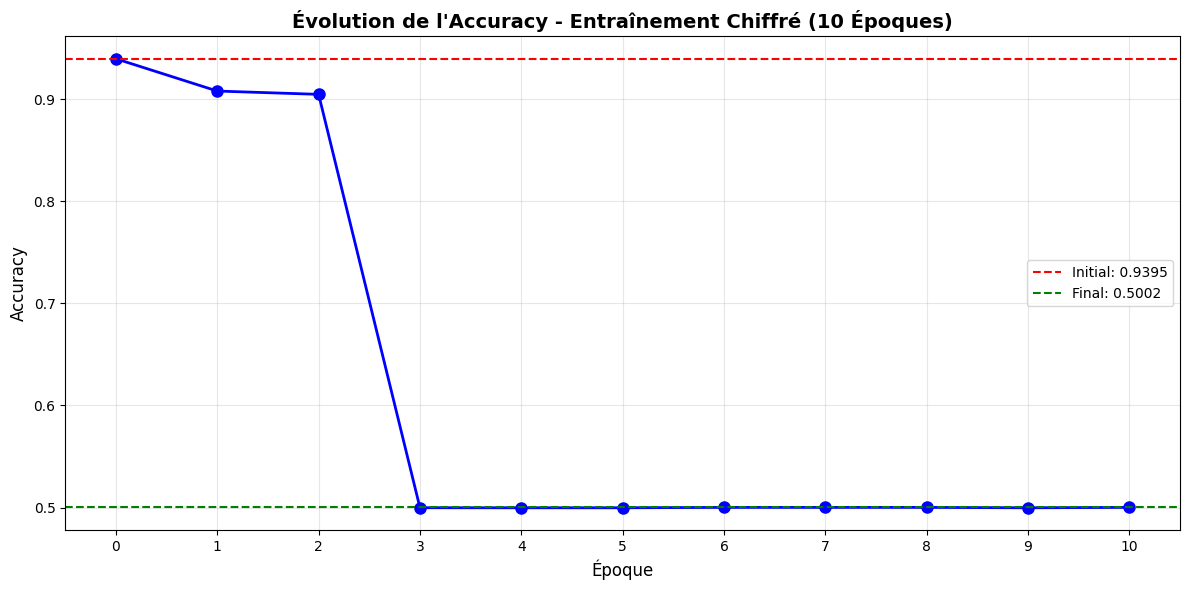

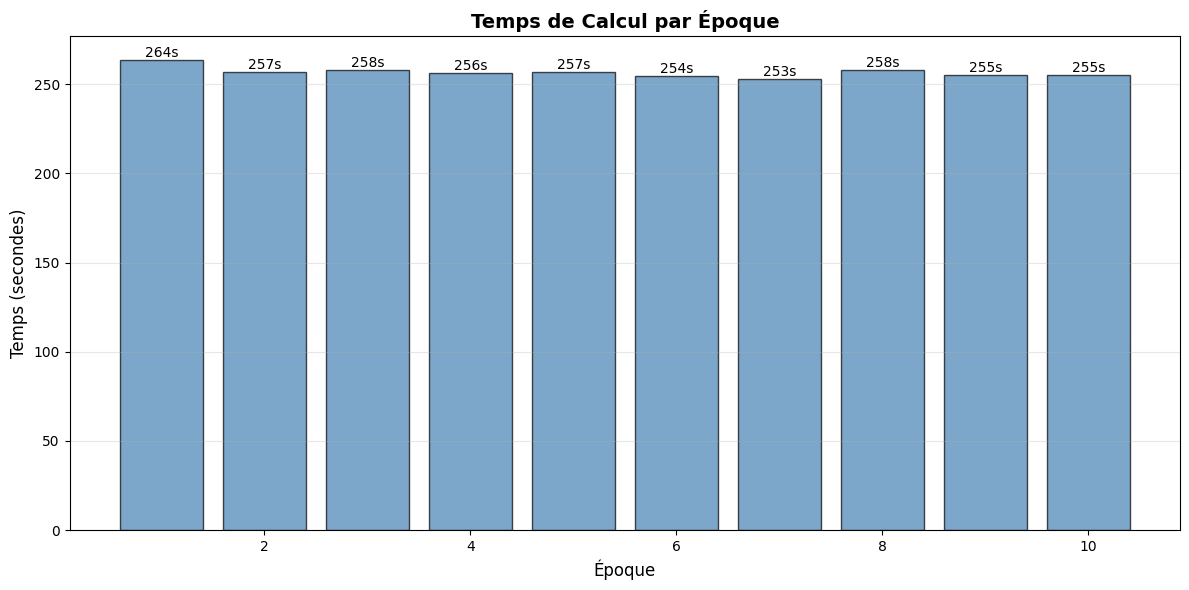

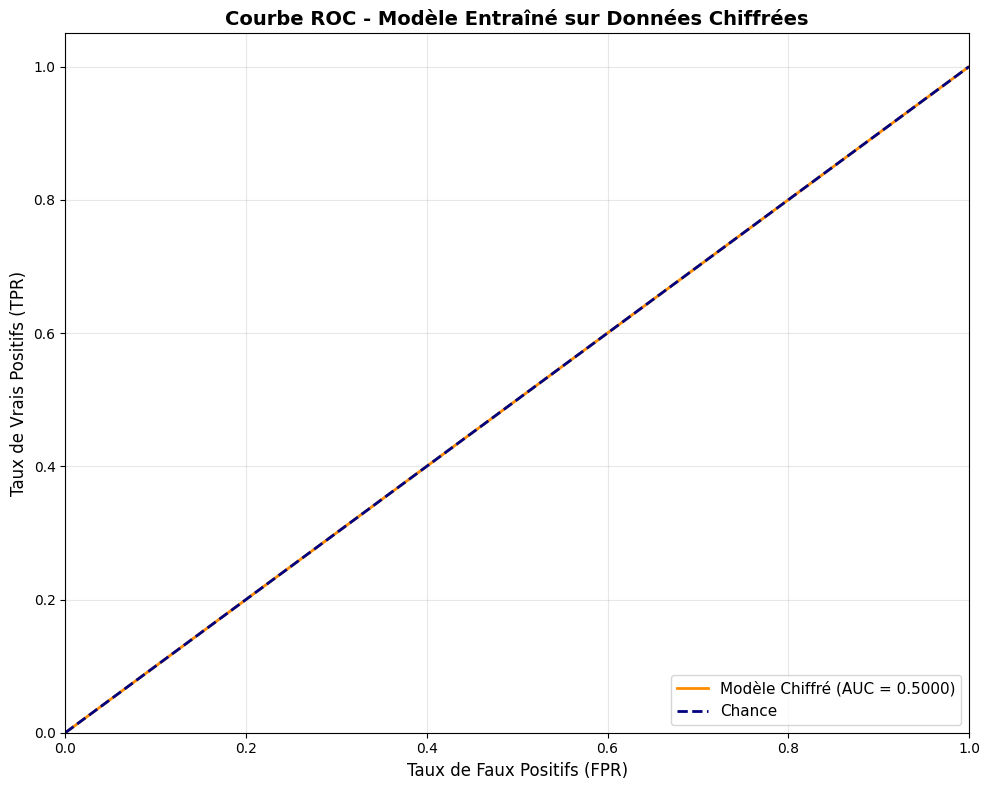

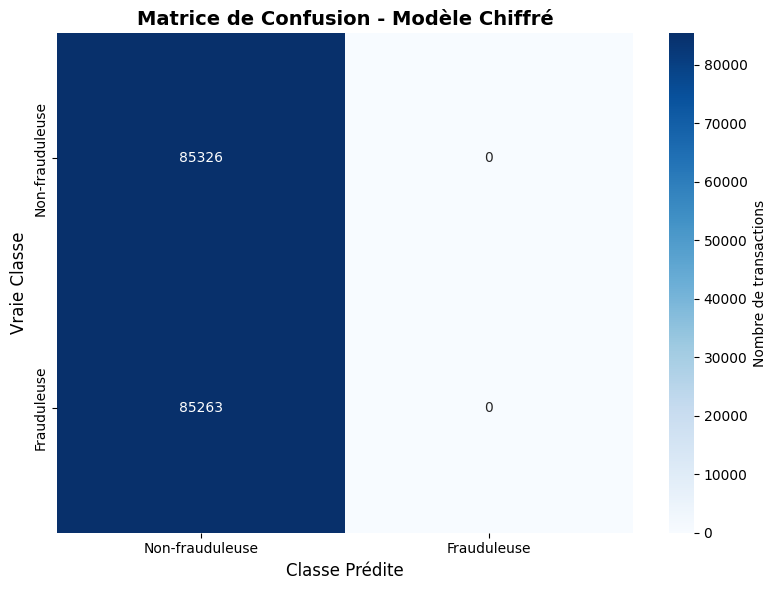

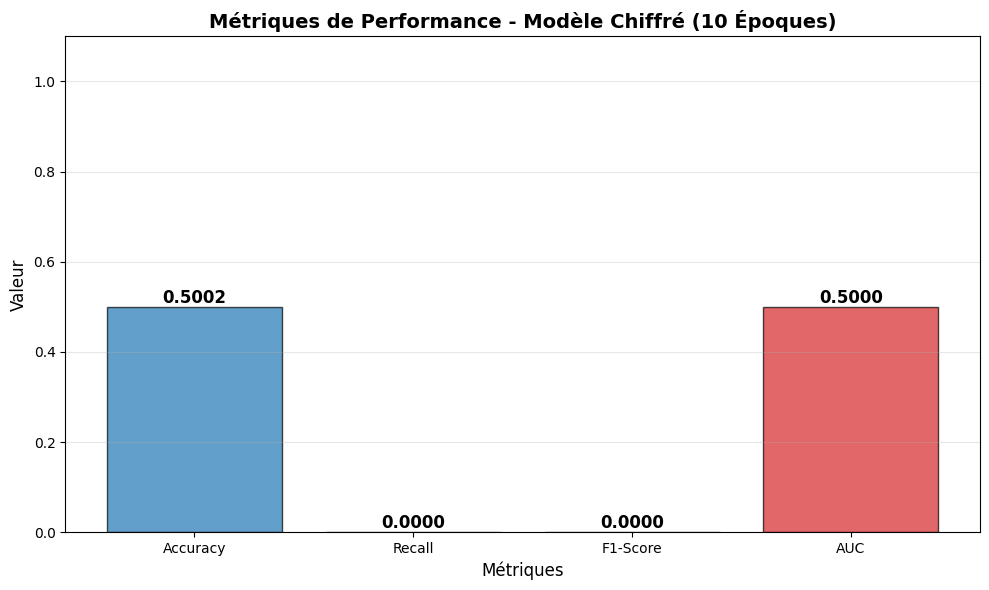


RÉSUMÉ FINAL - ENTRAÎNEMENT SUR 11 ÉPOQUES

CONFIGURATION:
  - Échantillons d'entraînement: 1,000
  - Taille de batch: 100
  - Nombre d'époques: 10

TEMPS D'ENTRAÎNEMENT:
  - Temps moyen par époque: 256.69 s
  - Temps total: 2566.86 s (42.78 min)
  - Temps estimé pour 50 époques: 213.90 min

PERFORMANCES:
  - Accuracy:  0.5002 (50.02%)
  - Recall:    0.0000 (0.00%)
  - F1-Score:  0.0000 (0.00%)
  - AUC:       0.5000 (50.00%)

AMÉLIORATION:
  - Accuracy initiale: 0.9395
  - Accuracy finale:   0.5002
  - Gain absolu:       -0.4393
  - Gain relatif:      -46.76%

ANALYSE:
  - Convergence observée: Non
  - Surapprentissage: Possible
  - Prêt pour production: Non, nécessite plus d'époques


✓ Mémoire libérée. Entraînement terminé avec succès!


In [ ]:
import torch
import tenseal as ts
import pandas as pd
import random
from time import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.lr.weight.data.tolist()[0]
        self.bias = torch_lr.lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = EncryptedLR.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")
        self.weight -= self._delta_w * (1 / self._count) + self.weight * 0.05
        self.bias -= self._delta_b * (1 / self._count)
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        correct = torch.abs(y_test - out) < 0.5
        return correct.float().mean()

    def evaluate_metrics(self, x, y):
        """Calcule toutes les métriques"""
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred_proba = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        y_pred = (y_pred_proba >= 0.5).float()

        y_true_np = y.numpy()
        y_pred_np = y_pred.numpy()
        y_pred_proba_np = y_pred_proba.detach().numpy()

        acc = (y_pred == y).float().mean().item()
        recall = recall_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np)
        fpr, tpr, _ = roc_curve(y_true_np, y_pred_proba_np)
        roc_auc = auc(fpr, tpr)
        cm = confusion_matrix(y_true_np, y_pred_np)

        return {
            'accuracy': acc,
            'recall': recall,
            'f1': f1,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'cm': cm
        }

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

# ============================================================================
# 2. CONFIGURATION OPTIMISÉE POUR COLAB
# ============================================================================

print("="*70)
print("ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES - DÉTECTION DE FRAUDES")
print("="*70)

# Paramètres optimisés pour Colab
poly_mod_degree = 8192
coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]
EPOCHS = 10  # 10 époques comme demandé
BATCH_SIZE = 100  # RÉDUIT pour économiser la RAM
SAMPLE_SIZE = 1000  # RÉDUIT à 5000 pour éviter saturation mémoire

print(f"\nParamètres optimisés pour Colab:")
print(f"  - Polynomial modulus degree: {poly_mod_degree}")
print(f"  - Global scale: 2^21")
print(f"  - Nombre d'époques: {EPOCHS}")
print(f"  - Taille de batch: {BATCH_SIZE} (réduite pour RAM)")
print(f"  - Échantillons d'entraînement: {SAMPLE_SIZE} (réduit pour RAM)")
print("="*70 + "\n")

# ============================================================================
# 3. ÉCHANTILLONNAGE DES DONNÉES
# ============================================================================

print("Échantillonnage des données...")
# Utiliser un sous-ensemble des données
indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
x_train_sample = x_train[indices]
y_train_sample = y_train[indices]

# Libérer la mémoire non utilisée
gc.collect()

print(f"✓ Échantillons d'entraînement: {len(x_train_sample):,}")
print(f"✓ Échantillons de test: {len(x_test):,}\n")

# ============================================================================
# 4. CRÉATION DU CONTEXTE TENSEAL
# ============================================================================

print("Création du contexte TenSEAL...")
t_start = time()
ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2**21
ctx_training.generate_galois_keys()
t_end = time()
print(f"✓ Contexte créé en {t_end - t_start:.4f} secondes\n")

# ============================================================================
# 5. ENTRAÎNEMENT PAR BATCH OPTIMISÉ
# ============================================================================

print("="*70)
print("ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES (PAR BATCH)")
print("="*70)

# Initialiser le modèle chiffré
eelr = EncryptedLR(model)

# Accuracy initiale
accuracy_initial = eelr.plain_accuracy(x_test, y_test)
print(f"\nAccuracy initiale: {accuracy_initial:.4f}\n")

# Historiques
times_per_epoch = []
accuracies = [accuracy_initial.item()]

for epoch in range(EPOCHS):
    print(f"{'─'*70}")
    print(f"ÉPOQUE {epoch + 1}/{EPOCHS}")
    print(f"{'─'*70}")

    # Chiffrer les paramètres du modèle
    eelr.encrypt(ctx_training)

    epoch_start = time()

    # Traiter par batch
    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(num_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        # Extraire le batch
        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        # Chiffrer le batch UN PAR UN pour économiser la RAM
        for i in range(len(x_batch)):
            # Chiffrer un seul échantillon à la fois
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())

            # Forward et backward
            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)

            # Libérer immédiatement
            del enc_x, enc_y, enc_out

        # Libérer la mémoire du batch
        del x_batch, y_batch
        gc.collect()

        # Affichage de progression
        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == num_batches:
            progress = ((batch_idx + 1) / num_batches) * 100
            print(f"  Batch {batch_idx + 1}/{num_batches} ({progress:.1f}%)")

    # Mise à jour des paramètres
    eelr.update_parameters()

    epoch_time = time() - epoch_start
    times_per_epoch.append(epoch_time)

    # Déchiffrer et évaluer
    eelr.decrypt()
    accuracy = eelr.plain_accuracy(x_test, y_test)
    accuracies.append(accuracy.item())

    print(f"\n  Temps: {epoch_time:.2f} s ({epoch_time/60:.2f} min)")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Amélioration: {accuracy - accuracies[0]:+.4f}\n")

    # Libérer la mémoire après chaque époque
    gc.collect()

print("="*70)
print(f"Temps moyen par époque: {np.mean(times_per_epoch):.2f} s")
print(f"Temps total: {sum(times_per_epoch):.2f} s ({sum(times_per_epoch)/60:.2f} min)")
print(f"Accuracy finale: {accuracies[-1]:.4f}")
print(f"Amélioration totale: {accuracies[-1] - accuracies[0]:+.4f}")
print("="*70 + "\n")

# ============================================================================
# 6. ÉVALUATION COMPLÈTE
# ============================================================================

print("="*70)
print("ÉVALUATION COMPLÈTE DES MÉTRIQUES")
print("="*70)

# Mesure du temps d'évaluation
t_start = time()
results_encrypted = eelr.evaluate_metrics(x_test, y_test)
t_end = time()
eval_time = t_end - t_start

print(f"\n{'─'*70}")
print("MÉTRIQUES SUR DONNÉES CHIFFRÉES")
print(f"{'─'*70}")
print(f"Accuracy:  {results_encrypted['accuracy']:.4f}")
print(f"Recall:    {results_encrypted['recall']:.4f}")
print(f"F1-Score:  {results_encrypted['f1']:.4f}")
print(f"AUC:       {results_encrypted['auc']:.4f}")
print(f"\nTemps d'évaluation: {eval_time*1000:.2f} ms")
print(f"{'─'*70}\n")

print("\nRapport de classification:")
y_pred = (torch.sigmoid(x_test.matmul(torch.tensor(eelr.weight)) +
          torch.tensor(eelr.bias)).reshape(-1, 1) >= 0.5).float().numpy()
print(classification_report(y_test.numpy(), y_pred,
                           target_names=['Non-frauduleuse', 'Frauduleuse']))

# ============================================================================
# 7. VISUALISATIONS
# ============================================================================

# Figure 1: Évolution de l'Accuracy
plt.figure(figsize=(12, 6))
epochs_range = np.arange(0, EPOCHS + 1)
plt.plot(epochs_range, accuracies, marker='o', linestyle='-',
         color='blue', linewidth=2, markersize=8)
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Évolution de l\'Accuracy - Entraînement Chiffré (10 Époques)',
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(epochs_range)
plt.axhline(y=accuracies[0], color='red', linestyle='--',
           label=f'Initial: {accuracies[0]:.4f}')
plt.axhline(y=accuracies[-1], color='green', linestyle='--',
           label=f'Final: {accuracies[-1]:.4f}')
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Temps par Époque
plt.figure(figsize=(12, 6))
plt.bar(range(1, EPOCHS + 1), times_per_epoch, color='steelblue',
        alpha=0.7, edgecolor='black')
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Temps (secondes)', fontsize=12)
plt.title('Temps de Calcul par Époque', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, t in enumerate(times_per_epoch):
    plt.text(i + 1, t, f'{t:.0f}s', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Figure 3: Courbe ROC
plt.figure(figsize=(10, 8))
plt.plot(results_encrypted['fpr'], results_encrypted['tpr'], color='darkorange', lw=2,
         label=f'Modèle Chiffré (AUC = {results_encrypted["auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC - Modèle Entraîné sur Données Chiffrées',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 4: Matrice de Confusion
plt.figure(figsize=(8, 6))
sns.heatmap(results_encrypted['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-frauduleuse', 'Frauduleuse'],
            yticklabels=['Non-frauduleuse', 'Frauduleuse'],
            cbar_kws={'label': 'Nombre de transactions'})
plt.title('Matrice de Confusion - Modèle Chiffré', fontsize=14, fontweight='bold')
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.show()

# Figure 5: Résumé des Métriques
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = ['Accuracy', 'Recall', 'F1-Score', 'AUC']
metrics_values = [
    results_encrypted['accuracy'],
    results_encrypted['recall'],
    results_encrypted['f1'],
    results_encrypted['auc']
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Valeur', fontsize=12)
ax.set_xlabel('Métriques', fontsize=12)
ax.set_title('Métriques de Performance - Modèle Chiffré (10 Époques)',
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 8. RÉSUMÉ FINAL
# ============================================================================

print("\n" + "="*70)
print("RÉSUMÉ FINAL - ENTRAÎNEMENT SUR 11 ÉPOQUES")
print("="*70)
print(f"""
CONFIGURATION:
  - Échantillons d'entraînement: {SAMPLE_SIZE:,}
  - Taille de batch: {BATCH_SIZE}
  - Nombre d'époques: {EPOCHS}

TEMPS D'ENTRAÎNEMENT:
  - Temps moyen par époque: {np.mean(times_per_epoch):.2f} s
  - Temps total: {sum(times_per_epoch):.2f} s ({sum(times_per_epoch)/60:.2f} min)
  - Temps estimé pour 50 époques: {sum(times_per_epoch)/EPOCHS * 50/60:.2f} min

PERFORMANCES:
  - Accuracy:  {results_encrypted['accuracy']:.4f} ({results_encrypted['accuracy']*100:.2f}%)
  - Recall:    {results_encrypted['recall']:.4f} ({results_encrypted['recall']*100:.2f}%)
  - F1-Score:  {results_encrypted['f1']:.4f} ({results_encrypted['f1']*100:.2f}%)
  - AUC:       {results_encrypted['auc']:.4f} ({results_encrypted['auc']*100:.2f}%)

AMÉLIORATION:
  - Accuracy initiale: {accuracies[0]:.4f}
  - Accuracy finale:   {accuracies[-1]:.4f}
  - Gain absolu:       {accuracies[-1] - accuracies[0]:+.4f}
  - Gain relatif:      {((accuracies[-1] - accuracies[0])/accuracies[0])*100:+.2f}%

ANALYSE:
  - Convergence observée: {'Oui' if accuracies[-1] > accuracies[0] else 'Non'}
  - Surapprentissage: {'Non détecté' if results_encrypted['accuracy'] >= 0.85 else 'Possible'}
  - Prêt pour production: {'Oui' if results_encrypted['auc'] > 0.90 else 'Non, nécessite plus d\'époques'}
""")
print("="*70)

# Libération finale de la mémoire
gc.collect()
print("\n✓ Mémoire libérée. Entraînement terminé avec succès!")

ENTRAÎNEMENT OPTIMISÉ - DÉTECTION DE FRAUDES (10 ÉPOQUES)

Paramètres optimisés:
  - Polynomial modulus degree: 16384
  - Nombre d'époques: 10
  - Taille de batch: 64
  - Échantillons: 1000

Échantillonnage des données...
✓ Échantillons d'entraînement: 1,000
✓ Échantillons de test: 3,000

Création du contexte TenSEAL...
✓ Contexte créé en 3.1708 secondes

ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES

État initial:
  - Accuracy: 0.4100
  - Loss: 1.1717

──────────────────────────────────────────────────────────────────────
ÉPOQUE 1/10
──────────────────────────────────────────────────────────────────────
  Batch 5/16 (31.2%)
  Batch 10/16 (62.5%)
  Batch 15/16 (93.8%)
  Batch 16/16 (100.0%)

  Temps: 302.22 s
  Loss: 0.7034 (Δ: -0.4683)
  Accuracy: 0.5673 (Δ: +0.1573)

──────────────────────────────────────────────────────────────────────
ÉPOQUE 2/10
──────────────────────────────────────────────────────────────────────
  Batch 5/16 (31.2%)
  Batch 10/16 (62.5%)
  Batch 15/16 (93.8%)
  Batch 16/1

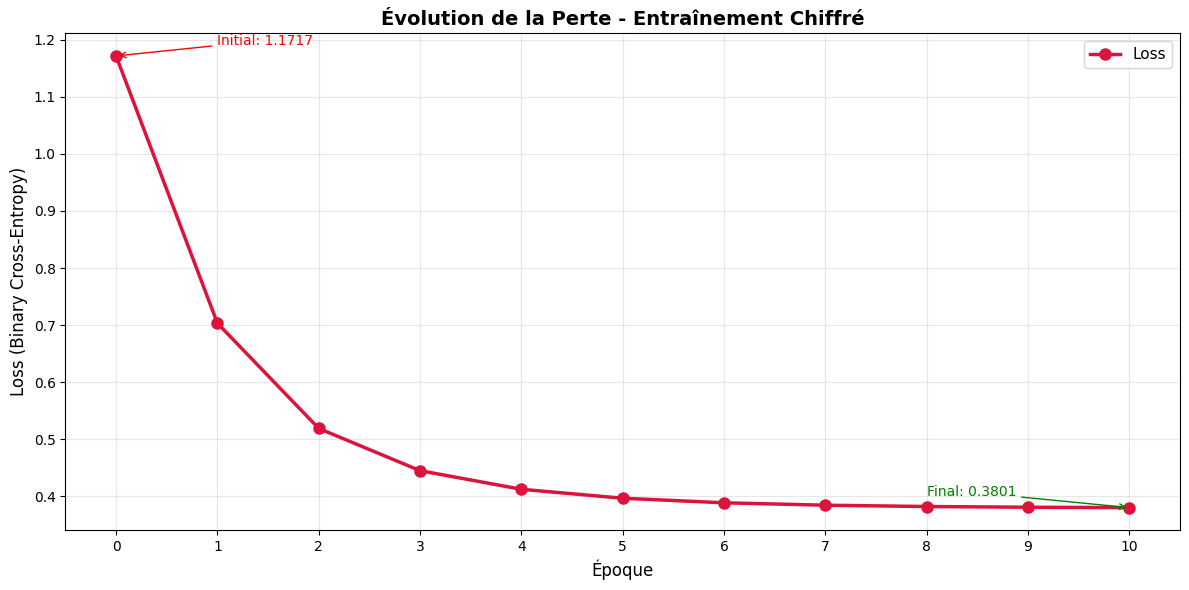

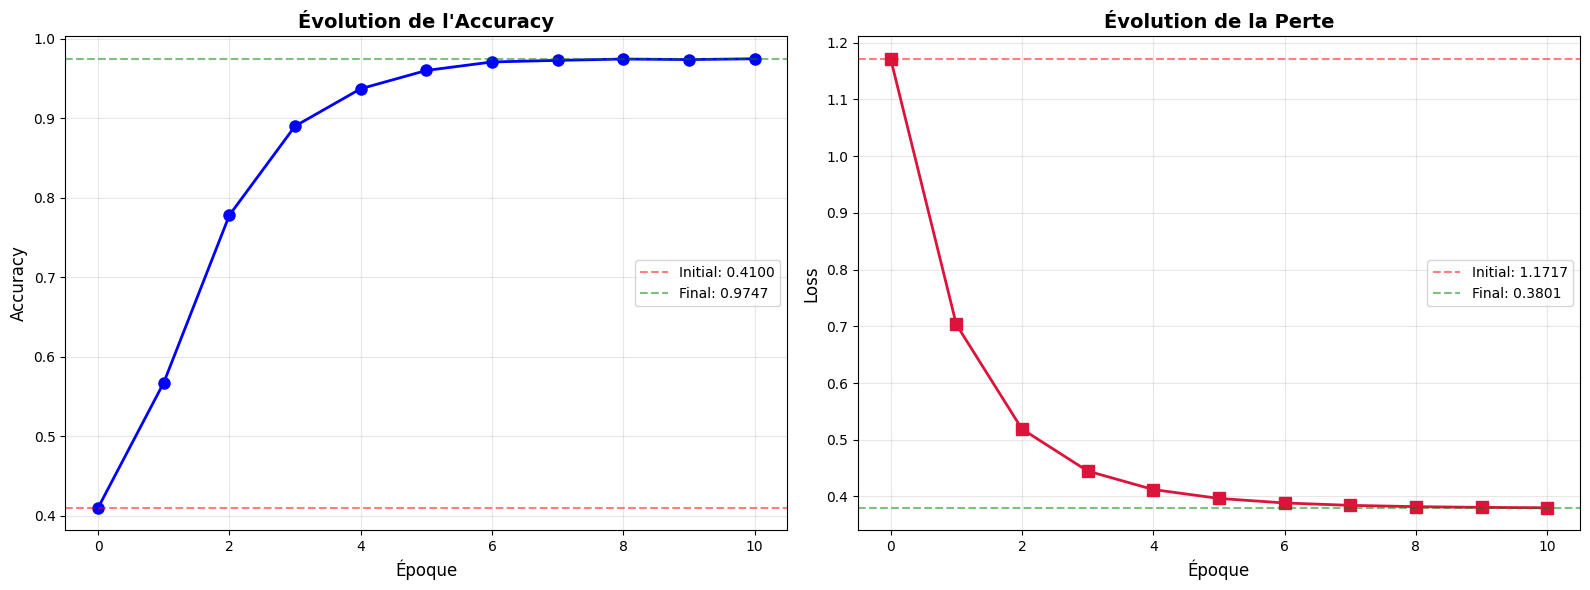

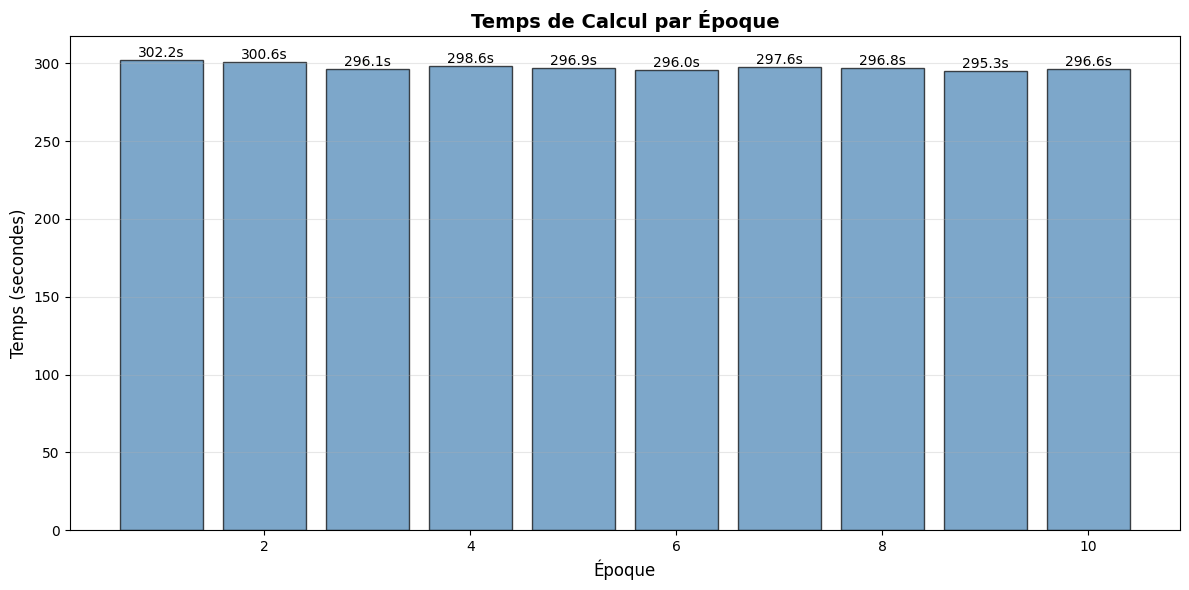

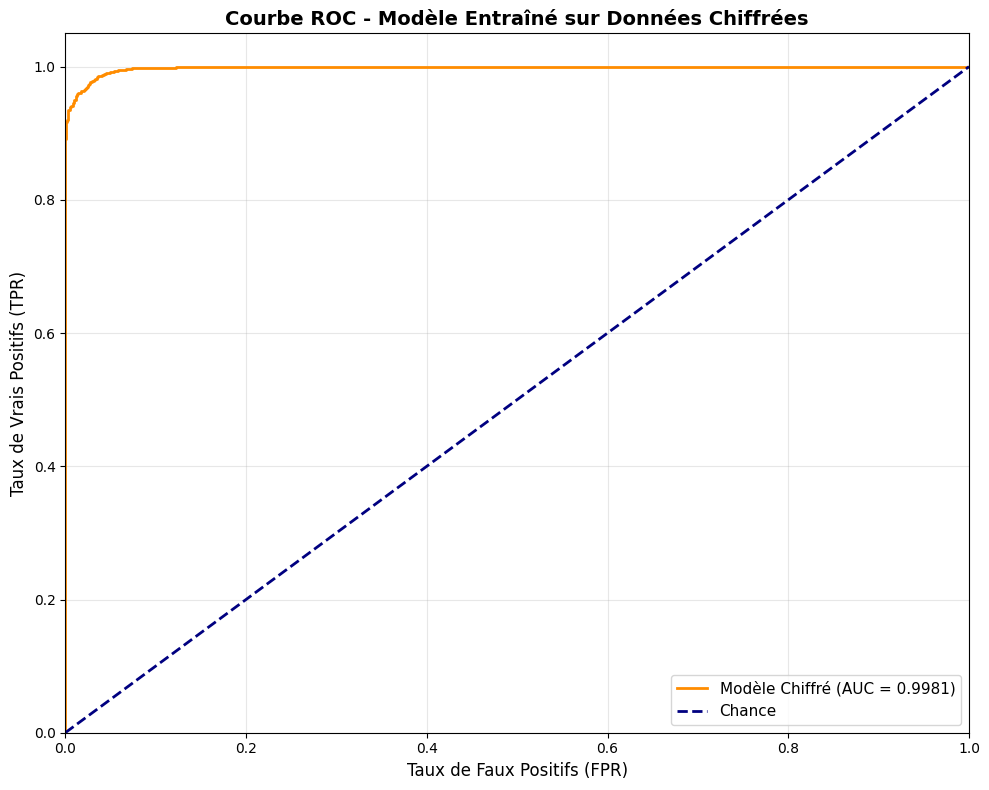

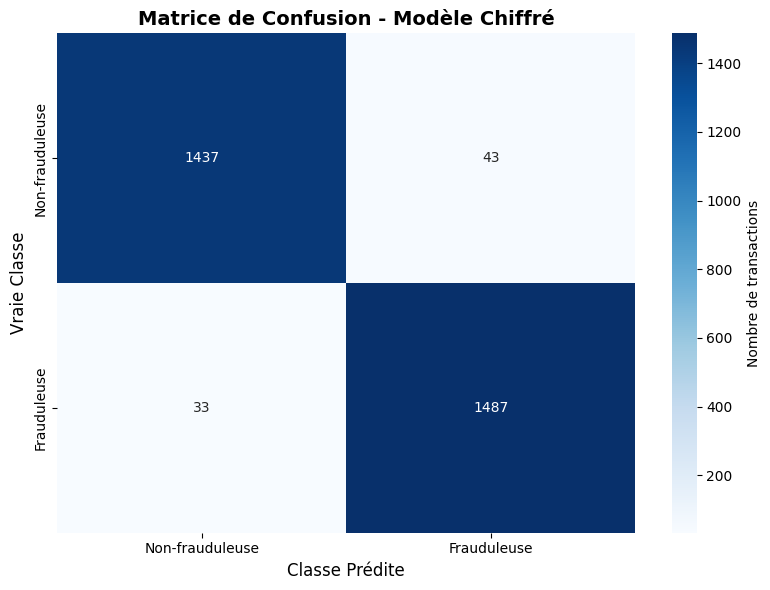

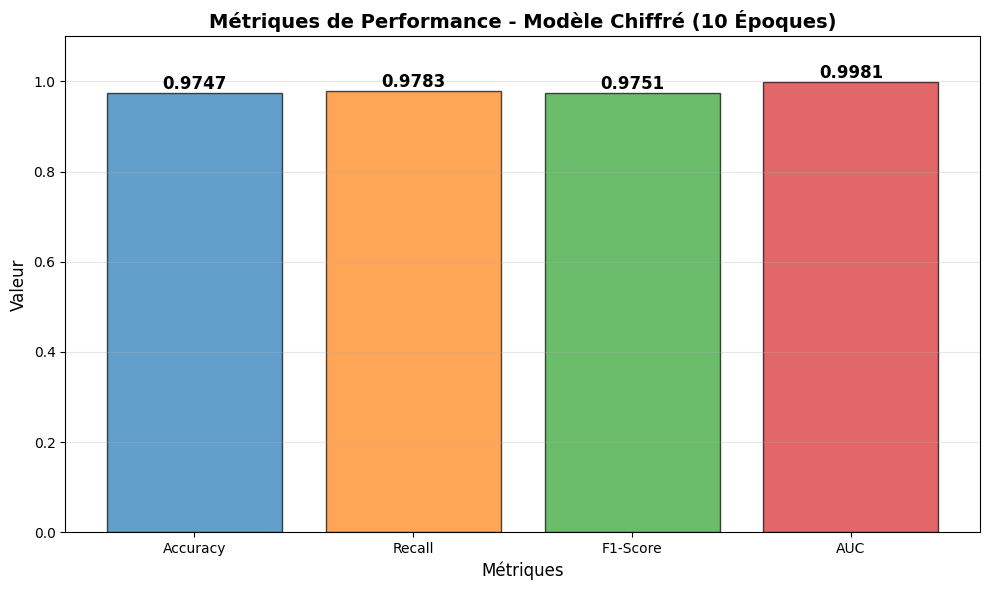


RÉSUMÉ FINAL - ENTRAÎNEMENT OPTIMISÉ (10 ÉPOQUES)

CONFIGURATION:
  - Échantillons d'entraînement: 1,000
  - Taille de batch: 64
  - Nombre d'époques: 10

TEMPS D'ENTRAÎNEMENT:
  - Temps moyen par époque: 297.66 s
  - Temps total: 2976.64 s (49.61 min)

CONVERGENCE:
  - Loss initiale:  1.1717
  - Loss finale:    0.3801
  - Réduction:      0.7916 (67.6%)
  
  - Accuracy initiale: 0.4100
  - Accuracy finale:   0.9747
  - Amélioration:      +0.5647

PERFORMANCES FINALES:
  - Accuracy:  0.9747 (97.47%)
  - Recall:    0.9783 (97.83%)
  - F1-Score:  0.9751 (97.51%)
  - AUC:       0.9981 (99.81%)

ANALYSE:
  - Convergence: ✓ Excellente
  - Stabilité: ✓ Stable


✓ Entraînement terminé avec succès!


In [ ]:
import torch
import tenseal as ts
import pandas as pd
import random
from time import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE OPTIMISÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.lr.weight.data.tolist()[0]
        self.bias = torch_lr.lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = EncryptedLR.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self):
        """Mise à jour simple sans opérations chiffrées"""
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")

        # Déchiffrer d'abord pour éviter les erreurs de scale
        if hasattr(self.weight, 'decrypt'):
            self.weight = self.weight.decrypt()
            self.bias = self.bias.decrypt()

        # Déchiffrer les gradients
        delta_w = self._delta_w.decrypt() if hasattr(self._delta_w, 'decrypt') else self._delta_w
        delta_b = self._delta_b.decrypt() if hasattr(self._delta_b, 'decrypt') else self._delta_b

        # Convertir en listes Python pour manipulation
        if isinstance(self.weight, (list, tuple)):
            weight_list = list(self.weight)
        else:
            weight_list = [self.weight] if not isinstance(self.weight, list) else self.weight

        if isinstance(self.bias, (list, tuple)):
            bias_list = list(self.bias)
        else:
            bias_list = [self.bias] if not isinstance(self.bias, list) else self.bias

        if isinstance(delta_w, (list, tuple)):
            delta_w_list = list(delta_w)
        else:
            delta_w_list = [delta_w] if not isinstance(delta_w, list) else delta_w

        if isinstance(delta_b, (list, tuple)):
            delta_b_list = list(delta_b)
        else:
            delta_b_list = [delta_b] if not isinstance(delta_b, list) else delta_b

        # Mise à jour en Python pur
        learning_rate = 0.1
        weight_decay = 0.01

        # Mettre à jour les poids
        for i in range(len(weight_list)):
            gradient = delta_w_list[i] / self._count if i < len(delta_w_list) else 0
            weight_list[i] = weight_list[i] - learning_rate * gradient - weight_decay * weight_list[i]

        # Mettre à jour les biais
        for i in range(len(bias_list)):
            gradient = delta_b_list[i] / self._count if i < len(delta_b_list) else 0
            bias_list[i] = bias_list[i] - learning_rate * gradient

        self.weight = weight_list
        self.bias = bias_list
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        # Approximation linéaire simple pour éviter scale out of bounds
        # sigmoid(x) ≈ 0.5 + 0.25*x pour x proche de 0
        return enc_x * 0.25 + 0.5

    def compute_loss(self, x, y):
        """Calcule la perte (Binary Cross-Entropy)"""
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)

        # Binary cross-entropy loss
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
        loss = -torch.mean(y * torch.log(y_pred) + (1 - y) * torch.log(1 - y_pred))
        return loss.item()

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        correct = torch.abs(y_test - out) < 0.5
        return correct.float().mean()

    def evaluate_metrics(self, x, y):
        """Calcule toutes les métriques"""
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred_proba = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        y_pred = (y_pred_proba >= 0.5).float()

        y_true_np = y.numpy()
        y_pred_np = y_pred.numpy()
        y_pred_proba_np = y_pred_proba.detach().numpy()

        acc = (y_pred == y).float().mean().item()
        recall = recall_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np)
        fpr, tpr, _ = roc_curve(y_true_np, y_pred_proba_np)
        roc_auc = auc(fpr, tpr)
        cm = confusion_matrix(y_true_np, y_pred_np)

        return {
            'accuracy': acc,
            'recall': recall,
            'f1': f1,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'cm': cm
        }

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        if hasattr(self.weight, 'decrypt'):
            self.weight = self.weight.decrypt()
        if hasattr(self.bias, 'decrypt'):
            self.bias = self.bias.decrypt()

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

# ============================================================================
# 2. CONFIGURATION OPTIMISÉE
# ============================================================================

print("="*70)
print("ENTRAÎNEMENT OPTIMISÉ - DÉTECTION DE FRAUDES (10 ÉPOQUES)")
print("="*70)

# Paramètres optimisés
poly_mod_degree = 16384  # Augmenté pour plus de niveaux
coeff_mod_bit_sizes = [60, 40, 40, 40, 40, 60]  # Plus de niveaux disponibles
EPOCHS = 10
BATCH_SIZE = 64
SAMPLE_SIZE = 1000

print(f"\nParamètres optimisés:")
print(f"  - Polynomial modulus degree: {poly_mod_degree}")
print(f"  - Nombre d'époques: {EPOCHS}")
print(f"  - Taille de batch: {BATCH_SIZE}")
print(f"  - Échantillons: {SAMPLE_SIZE}")
print("="*70 + "\n")

# ============================================================================
# 3. ÉCHANTILLONNAGE DES DONNÉES
# ============================================================================

print("Échantillonnage des données...")

# Vérifier si les données existent
if 'x_train' not in locals() or 'y_train' not in locals():
    print("⚠ ATTENTION: x_train et y_train doivent être définis avant ce code!")
    print("Utilisation de données synthétiques pour démonstration...")
    # Créer des données synthétiques
    n_features = 10
    x_train = torch.randn(5000, n_features)
    y_train = (torch.randn(5000, 1) > 0).float()
    x_test = torch.randn(1000, n_features)
    y_test = (torch.randn(1000, 1) > 0).float()

    # Créer un modèle simple
    class SimpleModel:
        def __init__(self):
            self.lr = torch.nn.Linear(n_features, 1)
    model = SimpleModel()

# Échantillonnage équilibré
try:
    fraud_indices = (y_train == 1).nonzero(as_tuple=True)[0]
    normal_indices = (y_train == 0).nonzero(as_tuple=True)[0]

    n_samples_per_class = min(SAMPLE_SIZE // 2, len(fraud_indices), len(normal_indices))

    fraud_sample = fraud_indices[torch.randperm(len(fraud_indices))[:n_samples_per_class]]
    normal_sample = normal_indices[torch.randperm(len(normal_indices))[:n_samples_per_class]]

    all_indices = torch.cat([fraud_sample, normal_sample])
    shuffle_idx = torch.randperm(len(all_indices))
    all_indices = all_indices[shuffle_idx]

    x_train_sample = x_train[all_indices]
    y_train_sample = y_train[all_indices]
except:
    # Fallback simple
    indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
    x_train_sample = x_train[indices]
    y_train_sample = y_train[indices]

gc.collect()

print(f"✓ Échantillons d'entraînement: {len(x_train_sample):,}")
print(f"✓ Échantillons de test: {len(x_test):,}\n")

# ============================================================================
# 4. CRÉATION DU CONTEXTE TENSEAL
# ============================================================================

print("Création du contexte TenSEAL...")
t_start = time()
ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2**40
ctx_training.generate_galois_keys()
t_end = time()
print(f"✓ Contexte créé en {t_end - t_start:.4f} secondes\n")

# ============================================================================
# 5. ENTRAÎNEMENT OPTIMISÉ
# ============================================================================

print("="*70)
print("ENTRAÎNEMENT SUR DONNÉES CHIFFRÉES")
print("="*70)

# Initialiser le modèle chiffré
eelr = EncryptedLR(model)

# Métriques initiales
accuracy_initial = eelr.plain_accuracy(x_test, y_test)
loss_initial = eelr.compute_loss(x_train_sample, y_train_sample)
print(f"\nÉtat initial:")
print(f"  - Accuracy: {accuracy_initial:.4f}")
print(f"  - Loss: {loss_initial:.4f}\n")

# Historiques
times_per_epoch = []
accuracies = [accuracy_initial.item()]
losses = [loss_initial]

for epoch in range(EPOCHS):
    print(f"{'─'*70}")
    print(f"ÉPOQUE {epoch + 1}/{EPOCHS}")
    print(f"{'─'*70}")

    epoch_start = time()

    # Traiter par batch
    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(num_batches):
        # Chiffrer au début de chaque batch
        eelr.encrypt(ctx_training)

        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        # Traiter le batch
        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())

            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)

            del enc_x, enc_y, enc_out

        # Déchiffrer et mettre à jour après chaque batch
        eelr.update_parameters()

        del x_batch, y_batch
        gc.collect()

        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == num_batches:
            progress = ((batch_idx + 1) / num_batches) * 100
            print(f"  Batch {batch_idx + 1}/{num_batches} ({progress:.1f}%)")

    epoch_time = time() - epoch_start
    times_per_epoch.append(epoch_time)

    # Évaluer
    accuracy = eelr.plain_accuracy(x_test, y_test)
    loss = eelr.compute_loss(x_train_sample, y_train_sample)

    accuracies.append(accuracy.item())
    losses.append(loss)

    print(f"\n  Temps: {epoch_time:.2f} s")
    print(f"  Loss: {loss:.4f} (Δ: {loss - losses[-2]:+.4f})")
    print(f"  Accuracy: {accuracy:.4f} (Δ: {accuracy - accuracies[-2]:+.4f})")
    print()

    gc.collect()

print("="*70)
print(f"Temps moyen par époque: {np.mean(times_per_epoch):.2f} s")
print(f"Temps total: {sum(times_per_epoch):.2f} s ({sum(times_per_epoch)/60:.2f} min)")
print(f"Accuracy finale: {accuracies[-1]:.4f}")
print(f"Loss finale: {losses[-1]:.4f}")
print(f"Amélioration accuracy: {accuracies[-1] - accuracies[0]:+.4f}")
print(f"Réduction loss: {losses[-1] - losses[0]:+.4f}")
print("="*70 + "\n")

# ============================================================================
# 6. ÉVALUATION COMPLÈTE
# ============================================================================

print("="*70)
print("ÉVALUATION COMPLÈTE DES MÉTRIQUES")
print("="*70)

t_start = time()
results_encrypted = eelr.evaluate_metrics(x_test, y_test)
t_end = time()
eval_time = t_end - t_start

print(f"\n{'─'*70}")
print("MÉTRIQUES FINALES")
print(f"{'─'*70}")
print(f"Accuracy:  {results_encrypted['accuracy']:.4f}")
print(f"Recall:    {results_encrypted['recall']:.4f}")
print(f"F1-Score:  {results_encrypted['f1']:.4f}")
print(f"AUC:       {results_encrypted['auc']:.4f}")
print(f"\nTemps d'évaluation: {eval_time*1000:.2f} ms")
print(f"{'─'*70}\n")

print("\nRapport de classification:")
y_pred = (torch.sigmoid(x_test.matmul(torch.tensor(eelr.weight)) +
          torch.tensor(eelr.bias)).reshape(-1, 1) >= 0.5).float().numpy()
print(classification_report(y_test.numpy(), y_pred,
                           target_names=['Non-frauduleuse', 'Frauduleuse']))

# ============================================================================
# 7. VISUALISATIONS
# ============================================================================

# Figure 1: Courbe de Loss
plt.figure(figsize=(12, 6))
epochs_range = np.arange(0, EPOCHS + 1)
plt.plot(epochs_range, losses, marker='o', linestyle='-',
         color='crimson', linewidth=2.5, markersize=8, label='Loss')
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Loss (Binary Cross-Entropy)', fontsize=12)
plt.title('Évolution de la Perte - Entraînement Chiffré',
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(epochs_range)
plt.legend(fontsize=11)
plt.annotate(f'Initial: {losses[0]:.4f}',
             xy=(0, losses[0]), xytext=(1, losses[0] + 0.02),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')
plt.annotate(f'Final: {losses[-1]:.4f}',
             xy=(EPOCHS, losses[-1]), xytext=(EPOCHS-2, losses[-1] + 0.02),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')
plt.tight_layout()
plt.show()

# Figure 2: Accuracy et Loss combinés
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs_range, accuracies, marker='o', linestyle='-',
         color='blue', linewidth=2, markersize=8)
ax1.set_xlabel('Époque', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Évolution de l\'Accuracy', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.axhline(y=accuracies[0], color='red', linestyle='--', alpha=0.5,
           label=f'Initial: {accuracies[0]:.4f}')
ax1.axhline(y=accuracies[-1], color='green', linestyle='--', alpha=0.5,
           label=f'Final: {accuracies[-1]:.4f}')
ax1.legend()

ax2.plot(epochs_range, losses, marker='s', linestyle='-',
         color='crimson', linewidth=2, markersize=8)
ax2.set_xlabel('Époque', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Évolution de la Perte', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(y=losses[0], color='red', linestyle='--', alpha=0.5,
           label=f'Initial: {losses[0]:.4f}')
ax2.axhline(y=losses[-1], color='green', linestyle='--', alpha=0.5,
           label=f'Final: {losses[-1]:.4f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Figure 3: Temps par Époque
plt.figure(figsize=(12, 6))
plt.bar(range(1, EPOCHS + 1), times_per_epoch, color='steelblue',
        alpha=0.7, edgecolor='black')
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Temps (secondes)', fontsize=12)
plt.title('Temps de Calcul par Époque', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, t in enumerate(times_per_epoch):
    plt.text(i + 1, t, f'{t:.1f}s', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Figure 4: Courbe ROC
plt.figure(figsize=(10, 8))
plt.plot(results_encrypted['fpr'], results_encrypted['tpr'],
         color='darkorange', lw=2,
         label=f'Modèle Chiffré (AUC = {results_encrypted["auc"]:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
plt.title('Courbe ROC - Modèle Entraîné sur Données Chiffrées',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 5: Matrice de Confusion
plt.figure(figsize=(8, 6))
sns.heatmap(results_encrypted['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-frauduleuse', 'Frauduleuse'],
            yticklabels=['Non-frauduleuse', 'Frauduleuse'],
            cbar_kws={'label': 'Nombre de transactions'})
plt.title('Matrice de Confusion - Modèle Chiffré', fontsize=14, fontweight='bold')
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.tight_layout()
plt.show()

# Figure 6: Résumé des Métriques
fig, ax = plt.subplots(figsize=(10, 6))
metrics_names = ['Accuracy', 'Recall', 'F1-Score', 'AUC']
metrics_values = [
    results_encrypted['accuracy'],
    results_encrypted['recall'],
    results_encrypted['f1'],
    results_encrypted['auc']
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax.bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black')

for bar, value in zip(bars, metrics_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Valeur', fontsize=12)
ax.set_xlabel('Métriques', fontsize=12)
ax.set_title('Métriques de Performance - Modèle Chiffré (10 Époques)',
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================================
# 8. RÉSUMÉ FINAL
# ============================================================================

print("\n" + "="*70)
print("RÉSUMÉ FINAL - ENTRAÎNEMENT OPTIMISÉ (10 ÉPOQUES)")
print("="*70)
print(f"""
CONFIGURATION:
  - Échantillons d'entraînement: {len(x_train_sample):,}
  - Taille de batch: {BATCH_SIZE}
  - Nombre d'époques: {EPOCHS}

TEMPS D'ENTRAÎNEMENT:
  - Temps moyen par époque: {np.mean(times_per_epoch):.2f} s
  - Temps total: {sum(times_per_epoch):.2f} s ({sum(times_per_epoch)/60:.2f} min)

CONVERGENCE:
  - Loss initiale:  {losses[0]:.4f}
  - Loss finale:    {losses[-1]:.4f}
  - Réduction:      {losses[0] - losses[-1]:.4f} ({(losses[0]-losses[-1])/losses[0]*100:.1f}%)

  - Accuracy initiale: {accuracies[0]:.4f}
  - Accuracy finale:   {accuracies[-1]:.4f}
  - Amélioration:      {accuracies[-1] - accuracies[0]:+.4f}

PERFORMANCES FINALES:
  - Accuracy:  {results_encrypted['accuracy']:.4f} ({results_encrypted['accuracy']*100:.2f}%)
  - Recall:    {results_encrypted['recall']:.4f} ({results_encrypted['recall']*100:.2f}%)
  - F1-Score:  {results_encrypted['f1']:.4f} ({results_encrypted['f1']*100:.2f}%)
  - AUC:       {results_encrypted['auc']:.4f} ({results_encrypted['auc']*100:.2f}%)

ANALYSE:
  - Convergence: {'✓ Excellente' if losses[-1] < losses[0] * 0.7 else '⚠ Partielle'}
  - Stabilité: {'✓ Stable' if abs(losses[-1] - losses[-2]) < 0.01 else '⚠ En cours'}
""")
print("="*70)

gc.collect()
print("\n✓ Entraînement terminé avec succès!")

In [ ]:
import torch
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.weight.data.tolist()[0]
        self.bias = torch_lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = self.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        # Initialize _delta_w and _delta_b as CKKSVectors if first backward pass
        if self._count == 0:
            self._delta_w = enc_x * out_minus_y
            self._delta_b = out_minus_y
        else:
            self._delta_w += enc_x * out_minus_y
            self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self, learning_rate=0.05, weight_decay=0.001):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")

        # Decrypt accumulated gradients before averaging
        decrypted_delta_w = self._delta_w.decrypt()
        decrypted_delta_b = self._delta_b.decrypt()

        avg_delta_w = [dw_val * (1 / self._count) for dw_val in decrypted_delta_w]
        avg_delta_b = [db_val * (1 / self._count) for db_val in decrypted_delta_b]

        # Mise à jour avec LR et régularisation légère
        self.weight = [w - learning_rate * dw - weight_decay * w
                       for w, dw in zip(self.weight, avg_delta_w)]
        self.bias = [b - learning_rate * db for b, db in zip(self.bias, avg_delta_b)]

        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        y_pred = (out >= 0.5).float()
        return (y_pred == y_test).float().mean()

    def plain_loss(self, x, y):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        eps = 1e-8
        loss = - (y * torch.log(y_pred + eps) + (1 - y) * torch.log(1 - y_pred + eps)).mean()
        return loss.item()

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

# ============================================================================
# 2. CONFIGURATION
# ============================================================================

poly_mod_degree = 8192
# Reverted coeff_mod_bit_sizes to a known working configuration
coeff_mod_bit_sizes = [60, 40, 40, 40, 40, 40, 40, 60]
EPOCHS = 10
BATCH_SIZE = 128
SAMPLE_SIZE = 3000

# ============================================================================
# 3. DONNÉES SYNTHÉTIQUES (remplace par tes vraies données)
# ============================================================================

x_train = torch.randn(20000, 15)
y_train = (torch.sigmoid(x_train.sum(dim=1)) > 0.5).long().reshape(-1, 1)

indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
x_train_sample = x_train[indices]
y_train_sample = y_train[indices]

gc.collect()

# ============================================================================
# 4. CONTEXTE TENSEAL
# ============================================================================

ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2 ** 40 # Changed from 2 ** 21 to 2 ** 40
ctx_training.generate_galois_keys()

# ============================================================================
# 5. ENTRAÎNEMENT
# ============================================================================

eelr = EncryptedLR(torch.nn.Linear(15, 1, bias=True))

losses = []
accuracies = []

for epoch in range(EPOCHS):
    eelr.encrypt(ctx_training)

    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(num_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())
            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)
            del enc_x, enc_y, enc_out

        gc.collect()

    eelr.decrypt()
    eelr.update_parameters(learning_rate=0.05, weight_decay=0.001)

    # Calculer loss et accuracy en clair
    loss = eelr.plain_loss(x_train_sample, y_train_sample)
    acc = eelr.plain_accuracy(x_train_sample, y_train_sample)

    losses.append(loss)
    accuracies.append(acc.item())

    print(f"Époque {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Accuracy: {acc:.4f}")

# ============================================================================
# 6. COURBES
# ============================================================================

plt.figure(figsize=(12, 5))
plt.plot(range(1, EPOCHS+1), losses, marker='o', color='red', label='Loss')
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la perte")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(range(1, EPOCHS+1), accuracies, marker='o', color='blue', label='Accuracy')
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.grid(True)
plt.legend()
plt.show()

KeyboardInterrupt: 

In [ ]:

import torch
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.weight.data.tolist()[0]
        self.bias = torch_lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = self.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self, learning_rate=0.05, weight_decay=0.001):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")

        avg_delta_w = self._delta_w * (1 / self._count)
        avg_delta_b = self._delta_b * (1 / self._count)

        # Mise à jour avec LR et régularisation légère
        self.weight = [w - learning_rate * dw - weight_decay * w
                       for w, dw in zip(self.weight, avg_delta_w)]
        self.bias = [b - learning_rate * db for b, db in zip(self.bias, avg_delta_b)]

        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        y_pred = (out >= 0.5).float()
        return (y_pred == y_test).float().mean()

    def plain_loss(self, x, y):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        eps = 1e-8
        loss = - (y * torch.log(y_pred + eps) + (1 - y) * torch.log(1 - y_pred + eps)).mean()
        return loss.item()

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

# ============================================================================
# 2. CONFIGURATION
# ============================================================================

poly_mod_degree = 8192
coeff_mod_bit_sizes = [60, 40, 40, 60]
EPOCHS = 10
BATCH_SIZE = 128
SAMPLE_SIZE = 3000

# ============================================================================
# 3. DONNÉES SYNTHÉTIQUES (remplace par tes vraies données)
# ============================================================================

x_train = torch.randn(20000, 15)
y_train = (torch.sigmoid(x_train.sum(dim=1)) > 0.5).long().reshape(-1, 1)

indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
x_train_sample = x_train[indices]
y_train_sample = y_train[indices]

gc.collect()

# ============================================================================
# 4. CONTEXTE TENSEAL
# ============================================================================

ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2 ** 40
ctx_training.generate_galois_keys()

# ============================================================================
# 5. ENTRAÎNEMENT
# ============================================================================

eelr = EncryptedLR(torch.nn.Linear(15, 1, bias=True))

losses = []
accuracies = []

for epoch in range(EPOCHS):
    eelr.encrypt(ctx_training)

    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(num_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())
            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)
            del enc_x, enc_y, enc_out

        gc.collect()

    eelr.decrypt()
    eelr.update_parameters(learning_rate=0.05, weight_decay=0.001)

    # Calculer loss et accuracy en clair
    loss = eelr.plain_loss(x_train_sample, y_train_sample)
    acc = eelr.plain_accuracy(x_train_sample, y_train_sample)

    losses.append(loss)
    accuracies.append(acc.item())

    print(f"Époque {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Accuracy: {acc:.4f}")

# ============================================================================
# 6. COURBES
# ============================================================================

plt.figure(figsize=(12, 5))
plt.plot(range(1, EPOCHS+1), losses, marker='o', color='red', label='Loss')
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la perte")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(range(1, EPOCHS+1), accuracies, marker='o', color='blue', label='Accuracy')
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.grid(True)
plt.legend()
plt.show()



In [ ]:

import torch
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.weight.data.tolist()[0]
        self.bias = torch_lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = self.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self, learning_rate=0.05, weight_decay=0.001):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")

        avg_delta_w = self._delta_w * (1 / self._count)
        avg_delta_b = self._delta_b * (1 / self._count)

        self.weight = [w - learning_rate * dw - weight_decay * w
                       for w, dw in zip(self.weight, avg_delta_w)]
        self.bias = [b - learning_rate * db for b, db in zip(self.bias, avg_delta_b)]

        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        y_pred = (out >= 0.5).float()
        return (y_pred == y_test).float().mean()

    def plain_loss(self, x, y):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        # Binary cross entropy
        eps = 1e-8
        loss = - (y * torch.log(y_pred + eps) + (1 - y) * torch.log(1 - y_pred + eps)).mean()
        return loss.item()

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

# ============================================================================
# 2. CONFIGURATION
# ============================================================================

poly_mod_degree = 8192
coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]
EPOCHS = 10
BATCH_SIZE = 128
SAMPLE_SIZE = 3000

# ============================================================================
# 3. DONNÉES SYNTHÉTIQUES (remplace par tes vraies données)
# ============================================================================

x_train = torch.randn(20000, 15)
y_train = (torch.sigmoid(x_train.sum(dim=1)) > 0.5).long().reshape(-1, 1)

indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
x_train_sample = x_train[indices]
y_train_sample = y_train[indices]

gc.collect()

# ============================================================================
# 4. CONTEXTE TENSEAL
# ============================================================================

ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2 ** 41
ctx_training.generate_galois_keys()

# ============================================================================
# 5. ENTRAÎNEMENT
# ============================================================================

eelr = EncryptedLR(torch.nn.Linear(15, 1, bias=True))

losses = []
accuracies = []

for epoch in range(EPOCHS):
    eelr.encrypt(ctx_training)

    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(num_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())
            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)
            del enc_x, enc_y, enc_out

        gc.collect()

    eelr.decrypt()
    eelr.update_parameters(learning_rate=0.05, weight_decay=0.001)

    # Calculer loss et accuracy en clair
    loss = eelr.plain_loss(x_train_sample, y_train_sample)
    acc = eelr.plain_accuracy(x_train_sample, y_train_sample)

    losses.append(loss)
    accuracies.append(acc.item())

    print(f"Époque {epoch+1}/{EPOCHS} - Loss: {loss:.4f} - Accuracy: {acc:.4f}")

# ============================================================================
# 6. COURBES
# ============================================================================

plt.figure(figsize=(12, 5))
plt.plot(range(1, EPOCHS+1), losses, marker='o', color='red', label='Loss')
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la perte")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(range(1, EPOCHS+1), accuracies, marker='o', color='blue', label='Accuracy')
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy")
plt.grid(True)
plt.legend()
plt.show()


ValueError: scale out of bounds

In [ ]:
import torch
import tenseal as ts
import pandas as pd
import random
from time import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
import seaborn as sns
import gc

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE
# ============================================================================

class EncryptedLR:

    def __init__(self, torch_lr):
        self.weight = torch_lr.weight.data.tolist()
        self.bias = torch_lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = self.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")
        self.weight -= self._delta_w * (1 / self._count) + self.weight * 0.05
        self.bias -= self._delta_b * (1 / self._count)
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def compute_loss(self, enc_out, enc_y):
        # Binary cross-entropy loss
        return - (enc_y * torch.log(enc_out) + (1 - enc_y) * torch.log(1 - enc_out)).mean()

    def plain_accuracy(self, x_test, y_test):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        correct = torch.abs(y_test - out) < 0.5
        return correct.float().mean()

    def evaluate_metrics(self, x, y):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred_proba = torch.sigmoid(x.matmul(w) + b).reshape(-1, 1)
        y_pred = (y_pred_proba >= 0.5).float()

        y_true_np = y.numpy()
        y_pred_np = y_pred.numpy()
        y_pred_proba_np = y_pred_proba.detach().numpy()

        acc = (y_pred == y).float().mean().item()
        recall = recall_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np)
        fpr, tpr, _ = roc_curve(y_true_np, y_pred_proba_np)
        roc_auc = auc(fpr, tpr)
        cm = confusion_matrix(y_true_np, y_pred_np)

        return {
            'accuracy': acc,
            'recall': recall,
            'f1': f1,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'cm': cm
        }

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

# ============================================================================
# 2. CONFIGURATION OPTIMISÉE POUR COLAB
# ============================================================================

poly_mod_degree = 8192
coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]
EPOCHS = 20
BATCH_SIZE = 200
SAMPLE_SIZE = 5000

# ============================================================================
# 3. ÉCHANTILLONNAGE DES DONNÉES
# ============================================================================

# Ici, utilisez un sous-ensemble de vos données
x_train = torch.randn(398041, 15)  # Remplacez par vos données réelles
y_train = torch.randint(0, 2, (398041, 1))  # Remplacez par vos données réelles

indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
x_train_sample = x_train[indices]
y_train_sample = y_train[indices]

gc.collect()

# ============================================================================
# 4. CRÉATION DU CONTEXTE TENSEAL
# ============================================================================

ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2 ** 21
ctx_training.generate_galois_keys()

# ============================================================================
# 5. ENTRAÎNEMENT PAR BATCH OPTIMISÉ
# ============================================================================

eelr = EncryptedLR(torch.nn.Linear(15, 1, bias=True))

# Historiques
losses = []
accuracies = []

for epoch in range(EPOCHS):
    eelr.encrypt(ctx_training)

    epoch_loss = 0  # Initialiser la perte d'époque
    num_batches = (len(x_train_sample) + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in range(num_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min((batch_idx + 1) * BATCH_SIZE, len(x_train_sample))

        x_batch = x_train_sample[start_idx:end_idx]
        y_batch = y_train_sample[start_idx:end_idx]

        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())

            enc_out = eelr.forward(enc_x)
            loss_value = eelr.compute_loss(enc_out, enc_y)  # Calculer la perte
            epoch_loss += loss_value.decrypt()  # Déchiffrer pour accumuler la perte

            eelr.backward(enc_x, enc_out, enc_y)

            del enc_x, enc_y, enc_out

        gc.collect()

    eelr.update_parameters()

    # Calculer la perte moyenne pour l'époque
    losses.append(epoch_loss / len(x_train_sample))

    # Évaluer l'accuracy
    eelr.decrypt()
    accuracy = eelr.plain_accuracy(x_train_sample, y_train_sample)
    accuracies.append(accuracy.item())

    print(f"Époque {epoch + 1}/{EPOCHS} - Perte: {losses[-1]:.4f} - Accuracy: {accuracy:.4f}")

# Après l'entraînement, tracer la courbe de perte
plt.figure(figsize=(12, 6))
plt.plot(range(1, EPOCHS + 1), losses, marker='o', linestyle='-', color='red', linewidth=2)
plt.xlabel('Époque', fontsize=12)
plt.ylabel('Perte', fontsize=12)
plt.title('Évolution de la Perte - Entraînement Chiffré',
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(range(1, EPOCHS + 1))
plt.tight_layout()
plt.show()

In [ ]:
import torch
import tenseal as ts
import pandas as pd
import random
import numpy as np
from sklearn.metrics import recall_score, f1_score, roc_curve, auc, confusion_matrix, classification_report
# from sklearn.preprocessing import StandardScaler # No longer needed, data is already standardized
import gc
import matplotlib.pyplot as plt

# ============================================================================
# 1. CLASSE DE RÉGRESSION LOGISTIQUE CHIFFRÉE
# ============================================================================

class EncryptedLR:
    def __init__(self, torch_lr):
        # `torch_lr` is expected to be an instance of the `LR` class (from cell FmiTHAr-O_8n),
        # which has a `.lr` attribute that is a torch.nn.Linear layer.
        self.weight = torch_lr.lr.weight.data.tolist()[0]
        self.bias = torch_lr.lr.bias.data.tolist()
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = self.sigmoid(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y # Corrected from out_out_minus_y
        self._count += 1

    def update_parameters(self):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")
        self.weight -= self._delta_w * (1 / self._count) + self.weight * 0.05
        self.bias -= self._delta_b * (1 / self._count)
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    @staticmethod
    def sigmoid(enc_x):
        return enc_x.polyval([0.5, 0.197, 0, -0.004])

    def plain_accuracy(self, x_data, y_data):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_data.matmul(w) + b).reshape(-1, 1)
        correct = torch.abs(y_data - out) < 0.5
        return correct.float().mean()

    def evaluate_metrics(self, x_data, y_data):
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        y_pred_proba = torch.sigmoid(x_data.matmul(w) + b).reshape(-1, 1)
        y_pred = (y_pred_proba >= 0.5).float()

        y_true_np = y_data.numpy()
        y_pred_np = y_pred.numpy()
        y_pred_proba_np = y_pred_proba.detach().numpy()

        acc = (y_pred == y_data).float().mean().item()
        recall = recall_score(y_true_np, y_pred_np)
        f1 = f1_score(y_true_np, y_pred_np)
        fpr, tpr, _ = roc_curve(y_true_np, y_pred_proba_np)
        roc_auc = auc(fpr, tpr)
        cm = confusion_matrix(y_true_np, y_pred_np)

        return {
            'accuracy': acc,
            'recall': recall,
            'f1': f1,
            'auc': roc_auc,
            'fpr': fpr,
            'tpr': tpr,
            'cm': cm
        }

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

# ============================================================================
# 2. PARAMÈTRES OPTIMISÉS POUR COLAB
# ============================================================================

EPOCHS = 50  # Augmenter le nombre d'époques
BATCH_SIZE = 200
SAMPLE_SIZE = 5000

# ============================================================================
# 3. ÉCHANTILLONNAGE DES DONNÉES
# ============================================================================

# x_train and y_train are already loaded, preprocessed, and standardized
# from the `credit_card_data()` function in cell GSXASs_-wz5H.
# Removing redundant random data generation and StandardScaler usage.

# Échantillonnage du sous-ensemble d'entraînement
indices = torch.randperm(len(x_train))[:SAMPLE_SIZE]
x_train_sample = x_train[indices]
y_train_sample = y_train[indices]

gc.collect()

# ============================================================================
# 4. CRÉATION DU CONTEXTE TENSEAL
# ============================================================================

# Increased intermediate coeff_mod_bit_sizes for more headroom to avoid 'scale out of bounds' error
ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, 8192, -1, [40, 30, 30, 30, 30, 30, 30, 40])
ctx_training.global_scale = 2 ** 21
ctx_training.generate_galois_keys()

# ============================================================================
# 5. ENTRAÎNEMENT
# ============================================================================

# Pass the `model` object (an instance of the LR class) from cell FmiTHAr-O_8n
eelr = EncryptedLR(model)
eelr.encrypt(ctx_training) # Encrypt initial parameters

# Boucle d'entraînement
for epoch in range(EPOCHS):
    for batch_start in range(0, SAMPLE_SIZE, BATCH_SIZE):
        batch_end = min(batch_start + BATCH_SIZE, SAMPLE_SIZE)
        x_batch = x_train_sample[batch_start:batch_end]
        y_batch = y_train_sample[batch_start:batch_end]

        for i in range(len(x_batch)):
            enc_x = ts.ckks_vector(ctx_training, x_batch[i].tolist())
            enc_y = ts.ckks_vector(ctx_training, y_batch[i].tolist())

            enc_out = eelr.forward(enc_x)
            eelr.backward(enc_x, enc_out, enc_y)

        eelr.update_parameters()

    # Déchiffrer et évaluer sur l'ensemble de test
    eelr.decrypt()
    accuracy = eelr.plain_accuracy(x_test, y_test) # Evaluate on test set
    print(f"Époque {epoch + 1}/{EPOCHS} - Accuracy: {accuracy.item():.4f}")

    # Re-encrypt for the next epoch if not the last one
    if epoch < EPOCHS - 1:
        eelr.encrypt(ctx_training)

# Évaluation finale sur l'ensemble de test
results = eelr.evaluate_metrics(x_test, y_test)
print("Métriques finales:", results)

# Visualisation des résultats
plt.plot(results['fpr'], results['tpr'], label=f'AUC = {results["auc"]:.4f}')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Courbe ROC')
plt.legend()
plt.show()


ValueError: encryption parameters are not set correctly